# Atobb vs TTLJ XGBoost Training and ONNX Export — senior-tree features

This is a minimally modified copy of the existing notebook.

Main change only:
- use the features stored by the senior `AtobbMLTree` ROOT tree
- do **not** reconstruct `A_mass_best`, `A_dr_best`, etc. from `TARGET_MA`

The rest of the training / weighting / validation / ONNX workflow is kept as close as possible to the original notebook.


## 1. Imports

Run this in the `MLHEP` kernel/environment where `ROOT`, `xgboost`, `onnxmltools`, and `skl2onnx` are installed.


In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import ROOT
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix

# [ADDED] train/validation overtraining test
from scipy.stats import ks_2samp

import onnx
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster
from skl2onnx.common.data_types import FloatTensorType

# [CHANGED]
# Use the same random seed everywhere instead of writing 42 repeatedly.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Input ROOT files

Change these paths if your files are somewhere else.


In [2]:
# ============================================================
# 2. Input ROOT files — combined MA training
# ============================================================

BASE_DIR = "/data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024"

SIGNAL_FILES_BY_MA = {
    18:  f"{BASE_DIR}/TTToHcToWAToBB-MHc130_MA18_SingleLepFilter.root",
    25:  f"{BASE_DIR}/TTToHcToWAToBB-MHc130_MA25_SingleLepFilter.root",
    36:  f"{BASE_DIR}/TTToHcToWAToBB-MHc130_MA36_SingleLepFilter.root",
    50:  f"{BASE_DIR}/TTToHcToWAToBB-MHc130_MA50_SingleLepFilter.root",
    70:  f"{BASE_DIR}/TTToHcToWAToBB-MHc130_MA70_SingleLepFilter.root",
    90:  f"{BASE_DIR}/TTToHcToWAToBB-MHc130_MA90_SingleLepFilter.root",
    110: f"{BASE_DIR}/TTToHcToWAToBB-MHc130_MA110_SingleLepFilter.root",
    125: f"{BASE_DIR}/TTToHcToWAToBB-MHc130_MA125_SingleLepFilter.root",
}

SIG_FILES = list(SIGNAL_FILES_BY_MA.values())

BKG_FILES = [
    f"{BASE_DIR}/TTLJ_powheg.root",
]

TREE_NAME = "Training_Tree"

TARGET_MHc = 130.0

# [REMOVED]
# TARGET_MA = 110.0
# Combined model does not assume one MA hypothesis.

MASS_POINTS = sorted(SIGNAL_FILES_BY_MA.keys())

MODEL_DIR = "/data9/Users/eunsu/MachineLearning/models"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_NAME = f"xgboost_atobb_MHc{int(TARGET_MHc)}_MAcombined_ttlj"

ONNX_PATH = f"{MODEL_DIR}/{MODEL_NAME}.onnx"
FEATURE_JSON_PATH = f"{MODEL_DIR}/{MODEL_NAME}_features.json"
SCALER_JSON_PATH = f"{MODEL_DIR}/{MODEL_NAME}_scaler.json"
SCALER_PICKLE_PATH = f"{MODEL_DIR}/{MODEL_NAME}_scaler.pkl"

N_BKG = 100000
NUM_BOOST_ROUND = 500
SCALER_TYPE = None

print("Signal files:")
for ma, p in SIGNAL_FILES_BY_MA.items():
    print(f"  MA={ma:3d}: {p}  exists={os.path.exists(p)}")

print("Background files:")
for p in BKG_FILES:
    print("  ", p, os.path.exists(p))

Signal files:
  MA= 18: /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc130_MA18_SingleLepFilter.root  exists=True
  MA= 25: /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc130_MA25_SingleLepFilter.root  exists=True
  MA= 36: /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc130_MA36_SingleLepFilter.root  exists=True
  MA= 50: /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc130_MA50_SingleLepFilter.root  exists=True
  MA= 70: /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc130_MA70_SingleLepFilter.root  exists=True
  MA= 90: /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc130_MA90_SingleLepFilter.root  exists=True
  MA=110: /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc130_MA110_SingleLepFilter.root  exists=True
  MA=125: /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc130_MA125_SingleLepFilter.root  exists=True
Background files:
   /data9/User

## 3. Load ROOT tree into pandas

This function reads only the branches we need, which is faster and safer than reading everything.


In [3]:
def read_training_tree(files, tree_name="Training_Tree", branches=None):
    dfs = []
    for path in files:
        if not os.path.exists(path):
            raise FileNotFoundError(path)
        f = ROOT.TFile.Open(path, "READ")
        if not f or f.IsZombie():
            raise RuntimeError(f"Cannot open ROOT file: {path}")
        tree = f.Get(tree_name)
        if not tree:
            raise RuntimeError(f"Cannot find tree '{tree_name}' in {path}")
        rdf = ROOT.RDataFrame(tree)
        if branches is None:
            arr = rdf.AsNumpy()
        else:
            arr = rdf.AsNumpy(branches)
        df = pd.DataFrame(arr)
        df["source_file"] = os.path.basename(path)
        dfs.append(df)
        f.Close()
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


## 4. Feature list

First-pass feature set. These are physics-motivated variables from `AtobbMLTree`: jet activity, b-tag topology, bb-pair masses, and ttbar reconstruction variables.

Do **not** include `label`, `weight_*`, or `source_file` as ML inputs.


In [4]:
# ============================================================
# [CHANGED] OLD TARGET_MA-DEPENDENT A RECONSTRUCTION DISABLED
# ============================================================
#
# The previous notebook built:
#
#   A_mass_best, A_dr_best, A_pt_best, ...
#
# by choosing
#
#   argmin |m_bb - TARGET_MA|
#
# among the raw bb pairs.
#
# For this notebook we intentionally DO NOT do that.
#
# The new ROOT files were produced with the senior AtobbMLTree,
# and the senior feature strategy feeds the individual bb
# combinations + higher-level signal-topology masses directly
# to XGBoost.
#
# TARGET_MHc / TARGET_MA are still kept in the input cell only
# for sample/model naming.
# ============================================================


In [4]:
# ============================================================
# 4. Feature configuration
# ============================================================

WEIGHT_COL = "weight_train"
LABEL_COL = "label"

BB_PAIRS = ["01", "02", "12", "03", "13", "23"]


# ============================================================
# Notebook-derived MA-independent bb summary features
# ============================================================

DERIVED_BB_SUMMARY_FEATURES = [
    "bb_mass_min_all", "bb_mass_max_all", "bb_mass_at_min_dr", "bb_dr_min_all"
]


# ============================================================
# [ADDED] TARGET_MA-dependent A-candidate features
#
# Candidate definition:
#
#   best pair = argmin |m_bb - TARGET_MA|
#
# IMPORTANT:
# Exactly the same TARGET_MA and reconstruction are applied
# to signal and background.
#
# First test:
#   use ONLY A_mass_best.
#
# Uncomment additional variables one at a time later.
# ============================================================

# DERIVED_A_FEATURES = [
    # "A_mass_best",

    # [OPTIONAL - test later]
    # "A_dr_best",
    # "bb_mass_diff_closest_target",
# ]


# ============================================================
# Final XGBoost features
# ============================================================

FEATURES = [
    # Event
    "HT", "ST", "MET_Pt",

    # Multiplicity
    "nJets", "nBJets",

    # Lepton
    "Lepton0_Pt", "Lepton0_Eta",

    # --------------------------------------------------------
    # MA-independent bb summaries
    # --------------------------------------------------------
    "bb_mass_min_all", "bb_mass_max_all", "bb_mass_at_min_dr", "bb_dr_min_all",

    # --------------------------------------------------------
    # Direct bb pair information
    #
    # 03/13/23 raw bb mass/dr remain excluded from direct ML
    # input because they strongly encoded the fourth-b topology.
    # --------------------------------------------------------
    "bb_mass_01", "bb_mass_02", "bb_mass_12",
    "bb_dr_01", "bb_dr_02", "bb_dr_12",

    # --------------------------------------------------------
    # [ADDED] TARGET_MA-dependent A candidate
    # --------------------------------------------------------
    # "A_mass_best",

    # [OPTIONAL - uncomment together with DERIVED_A_FEATURES]
    # "A_dr_best",
    # "bb_mass_diff_closest_target",

    # --------------------------------------------------------
    # Composite masses
    # --------------------------------------------------------
    "bblnu_mass_01", "bblnu_mass_02", "bblnu_mass_12",

    # Fourth-b bblnu combinations remain excluded
    # "bblnu_mass_03", "bblnu_mass_13", "bblnu_mass_23",

    "bbjj_mass_01", "bbjj_mass_02", "bbjj_mass_12",
    # "bbjj_mass_03", "bbjj_mass_13", "bbjj_mass_23",

    "bbbW_mass_012", 
    # "bbbW_mass_013", "bbbW_mass_023", "bbbW_mass_123",
    # "bW_mass_013", "bW_mass_023", "bW_mass_123",

    # W reconstruction
    "lnu_mass", "jj_mass",

    # ttbar hypothesis
    "best_chi2", "had_W_mass", "had_top_mass", "lep_W_mass", "lep_top_mass",
]


# ============================================================
# All notebook-derived features
#
# These must NOT be searched for in the ROOT tree.
# ============================================================

# DERIVED_FEATURES = DERIVED_BB_SUMMARY_FEATURES + DERIVED_A_FEATURES
DERIVED_FEATURES = DERIVED_BB_SUMMARY_FEATURES

# ============================================================
# Auxiliary bb branches
#
# Read all six pairs because they are needed for:
#
#   1. bb summary reconstruction
#   2. TARGET_MA-dependent A candidate reconstruction
#
# 03/13/23 are READ but are not necessarily direct XGBoost
# inputs.
# ============================================================

BB_SOURCE_BRANCHES = [
    "bb_mass_01", "bb_mass_02", "bb_mass_12", "bb_mass_03", "bb_mass_13", "bb_mass_23",
    "bb_dr_01", "bb_dr_02", "bb_dr_12", "bb_dr_03", "bb_dr_13", "bb_dr_23",
]


# ============================================================
# ROOT branches actually required
# ============================================================

ROOT_FEATURES_TO_READ = [
    feat for feat in FEATURES
    if feat not in DERIVED_FEATURES
]

BRANCHES_TO_READ = sorted(set(
    ROOT_FEATURES_TO_READ
    + BB_SOURCE_BRANCHES
    + [WEIGHT_COL, "weight_nominal", LABEL_COL]
))


print(f"Number of final ML features = {len(FEATURES)}")
print(FEATURES)

print()
print(f"Number of ROOT branches to read = {len(BRANCHES_TO_READ)}")
print(BRANCHES_TO_READ)

print()
print("Derived in notebook:", DERIVED_FEATURES)
print("Auxiliary only:", [x for x in BB_SOURCE_BRANCHES if x not in FEATURES])

Number of final ML features = 31
['HT', 'ST', 'MET_Pt', 'nJets', 'nBJets', 'Lepton0_Pt', 'Lepton0_Eta', 'bb_mass_min_all', 'bb_mass_max_all', 'bb_mass_at_min_dr', 'bb_dr_min_all', 'bb_mass_01', 'bb_mass_02', 'bb_mass_12', 'bb_dr_01', 'bb_dr_02', 'bb_dr_12', 'bblnu_mass_01', 'bblnu_mass_02', 'bblnu_mass_12', 'bbjj_mass_01', 'bbjj_mass_02', 'bbjj_mass_12', 'bbbW_mass_012', 'lnu_mass', 'jj_mass', 'best_chi2', 'had_W_mass', 'had_top_mass', 'lep_W_mass', 'lep_top_mass']

Number of ROOT branches to read = 36
['HT', 'Lepton0_Eta', 'Lepton0_Pt', 'MET_Pt', 'ST', 'bb_dr_01', 'bb_dr_02', 'bb_dr_03', 'bb_dr_12', 'bb_dr_13', 'bb_dr_23', 'bb_mass_01', 'bb_mass_02', 'bb_mass_03', 'bb_mass_12', 'bb_mass_13', 'bb_mass_23', 'bbbW_mass_012', 'bbjj_mass_01', 'bbjj_mass_02', 'bbjj_mass_12', 'bblnu_mass_01', 'bblnu_mass_02', 'bblnu_mass_12', 'best_chi2', 'had_W_mass', 'had_top_mass', 'jj_mass', 'label', 'lep_W_mass', 'lep_top_mass', 'lnu_mass', 'nBJets', 'nJets', 'weight_nominal', 'weight_train']

Derived i

In [5]:
# ============================================================
# 5. Reconstruct MA-independent bb summary features
# ============================================================

def add_bb_summary_features(df):
    out = df.copy()

    mass_cols = [f"bb_mass_{pair}" for pair in BB_PAIRS]
    dr_cols = [f"bb_dr_{pair}" for pair in BB_PAIRS]

    masses = out[mass_cols].to_numpy(dtype=float)
    drs = out[dr_cols].to_numpy(dtype=float)

    # mass/dr가 둘 다 physical한 pair만 사용
    valid = np.isfinite(masses) & np.isfinite(drs) & (masses > 0.0) & (drs > 0.0)
    has_valid_pair = np.any(valid, axis=1)

    # min/max bb mass
    out["bb_mass_min_all"] = np.min(np.where(valid, masses, np.inf), axis=1)
    out["bb_mass_max_all"] = np.max(np.where(valid, masses, -np.inf), axis=1)

    # minimum DeltaR pair
    dr_for_min = np.where(valid, drs, np.inf)
    min_dr_idx = np.argmin(dr_for_min, axis=1)
    row_idx = np.arange(len(out))

    out["bb_dr_min_all"] = drs[row_idx, min_dr_idx]
    out["bb_mass_at_min_dr"] = masses[row_idx, min_dr_idx]

    # valid pair 자체가 없는 event
    derived_cols = ["bb_mass_min_all", "bb_mass_max_all", "bb_mass_at_min_dr", "bb_dr_min_all"]
    out.loc[~has_valid_pair, derived_cols] = np.nan

    return out

In [6]:
# ============================================================
# 6. ROOT branch check
# ============================================================

def check_required_branches(root_path, tree_name, required_branches):
    f = ROOT.TFile.Open(root_path, "READ")
    if not f or f.IsZombie():
        raise RuntimeError(f"Cannot open ROOT file: {root_path}")

    tree = f.Get(tree_name)
    if not tree:
        f.Close()
        raise RuntimeError(f"Cannot find tree '{tree_name}' in {root_path}")

    available = {b.GetName() for b in tree.GetListOfBranches()}
    missing = [b for b in required_branches if b not in available]

    print(f"\nROOT: {root_path}")
    print(f"  available branches = {len(available)}")
    print(f"  required branches  = {len(required_branches)}")

    if missing:
        print("  [MISSING]", missing)
        f.Close()
        raise RuntimeError("Required ROOT branches are missing.")

    print("  [OK] all requested branches exist")
    f.Close()

check_required_branches(SIG_FILES[0], TREE_NAME, BRANCHES_TO_READ)
check_required_branches(BKG_FILES[0], TREE_NAME, BRANCHES_TO_READ)


ROOT: /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc130_MA18_SingleLepFilter.root
  available branches = 129
  required branches  = 36
  [OK] all requested branches exist

ROOT: /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTLJ_powheg.root
  available branches = 129
  required branches  = 36
  [OK] all requested branches exist


In [7]:
# ============================================================
# 7. Read combined signal and background
# ============================================================

sig_dfs = []

for ma, path in SIGNAL_FILES_BY_MA.items():
    df = read_training_tree(
        [path],
        TREE_NAME,
        branches=BRANCHES_TO_READ,
    )

    df = add_bb_summary_features(df)

    # evaluation/debugging용. ML input에는 들어가지 않음.
    df["mass_point"] = ma
    df[LABEL_COL] = 1

    sig_dfs.append(df)

df_sig = pd.concat(sig_dfs, ignore_index=True)

df_bkg = read_training_tree(
    BKG_FILES,
    TREE_NAME,
    branches=BRANCHES_TO_READ,
)

df_bkg = add_bb_summary_features(df_bkg)
df_bkg["mass_point"] = -1
df_bkg[LABEL_COL] = 0

print("Signal entries by MA:")
print(df_sig.groupby("mass_point").size())

print()
print("Total signal entries:", len(df_sig))
print("Background entries before limit:", len(df_bkg))

if N_BKG is not None and len(df_bkg) > N_BKG:
    df_bkg = (
        df_bkg
        .sample(n=N_BKG, random_state=RANDOM_SEED)
        .reset_index(drop=True)
    )

print("Background entries after limit:", len(df_bkg))

missing_sig = [x for x in FEATURES if x not in df_sig.columns]
missing_bkg = [x for x in FEATURES if x not in df_bkg.columns]

print("Missing final signal features:", missing_sig)
print("Missing final background features:", missing_bkg)

assert not missing_sig
assert not missing_bkg

Signal entries by MA:
mass_point
18     13011
25     14319
36     14207
50     17756
70     17393
90     15765
110    12045
125    10895
dtype: int64

Total signal entries: 115391
Background entries before limit: 224928
Background entries after limit: 100000
Missing final signal features: []
Missing final background features: []


## 5. Read signal and background samples

For this notebook, we override the label explicitly to avoid relying on sample-name parsing.


In [8]:
# ============================================================
# [CHANGED] Senior-tree feature sanity check
#
# Replaces the old A_pair_name / A_mass_best debugging cell.
# ============================================================

CHECK_COLS = [
    "nJets",
    "nBJets",
    "bb_mass_01",
    "bb_mass_02",
    "bb_mass_12",
    # "bb_mass_03",
    "bb_dr_01",
    "bb_dr_02",
    "bb_dr_12",
    # "bb_dr_03",
    "bblnu_mass_01",
    "bbjj_mass_01",
    "bbbW_mass_012",
    # "bW_mass_013",
    "lnu_mass",
    "jj_mass",

    # [ADDED] A candidate sanity check
    # "A_pair_name", "A_mass_best", "A_dr_best", "bb_mass_diff_closest_target",
]

print("[Signal]")
display(df_sig[CHECK_COLS].head(10))

print("\n[Background]")
display(df_bkg[CHECK_COLS].head(10))


[Signal]


,nJets,nBJets,bb_mass_01,bb_mass_02,bb_mass_12,bb_dr_01,bb_dr_02,bb_dr_12,bblnu_mass_01,bbjj_mass_01,bbbW_mass_012,lnu_mass,jj_mass
0,14,3,59.073715,43.409264,22.530691,0.921244,1.092571,0.627350,215.292053,487.804657,232.613373,97.320419,288.272919
1,10,3,97.422569,66.247604,20.872393,1.840047,1.336767,0.608763,228.172134,663.436218,245.698059,117.171906,330.904419
2,7,3,381.456543,266.346527,61.981892,3.363143,3.077124,0.741534,462.629639,678.770996,552.687073,79.027924,279.565277
3,6,4,276.348541,267.784607,39.050896,3.039462,3.039019,0.421673,367.745880,461.306793,488.766907,17.063141,40.254368
4,8,3,233.798386,79.002525,207.631943,3.023592,0.722833,3.256338,342.095856,1723.909912,417.243683,79.117035,1165.385742
5,7,3,193.607315,145.110062,39.033085,3.038026,3.331038,0.704392,695.714172,595.178223,620.602600,352.921661,271.582886
6,7,3,70.594627,189.149231,115.718224,0.924870,2.796945,2.368004,382.168884,244.713562,364.742310,83.555214,38.649120
7,8,4,334.198334,162.816208,55.673592,2.996850,2.445768,0.593951,599.269470,539.380554,601.685974,213.535431,60.754471
8,8,3,78.869652,43.962605,35.192398,1.531360,0.677048,1.083827,271.590668,214.140900,244.998001,89.081718,60.920174
9,8,4,140.102249,54.380463,82.456940,2.346602,0.980609,3.042430,271.641998,575.148682,300.071991,102.739319,385.112885



[Background]


,nJets,nBJets,bb_mass_01,bb_mass_02,bb_mass_12,bb_dr_01,bb_dr_02,bb_dr_12,bblnu_mass_01,bbjj_mass_01,bbbW_mass_012,lnu_mass,jj_mass
0,8,3,405.109070,210.181931,125.648766,2.977167,2.131197,1.451683,502.398926,630.490601,584.286865,33.963837,136.718918
1,10,3,144.416016,114.569817,118.872246,1.212997,2.281724,2.979152,816.022583,1729.034058,860.083130,262.988861,1458.168457
2,9,3,182.060486,170.055206,96.691086,2.717481,2.580737,1.605147,432.247437,499.032990,540.999695,220.476608,121.892830
3,10,3,84.359215,124.301918,52.814594,0.845240,2.134167,1.323243,346.922211,812.615479,405.080566,160.524033,458.836029
4,13,3,191.866913,132.391205,69.467537,2.598781,2.800606,1.491486,315.312439,657.801636,361.245422,41.578506,233.430130
5,9,3,312.864594,93.226112,37.847847,3.472315,2.776726,0.784543,462.827271,588.331177,483.803680,63.323067,83.144463
6,7,3,173.625671,132.357697,70.304787,1.984970,1.836716,2.136147,404.259735,579.083496,464.974762,99.975494,73.793549
7,8,3,79.543076,112.914070,95.287590,1.038685,1.416949,2.259332,253.315262,404.064178,299.664215,48.872551,81.717743
8,8,3,307.720001,205.527786,105.311409,1.602289,1.448953,1.078420,494.550323,1826.051025,572.569885,59.294491,1194.856934
9,10,3,154.161499,91.992424,71.694115,3.512046,2.004839,2.600752,394.468964,616.704651,419.818024,78.650330,431.643707


## 6. Basic cleaning and weight handling

- Replace `inf` with `NaN`
- Drop rows with invalid feature/weight values
- Use `abs(weight_train)` by default for training stability
- Normalize total signal/background weights to similar scale

If you want signed MC weights later, keep them for final histograms, but for first classifier training this is safer.


In [9]:
def print_bad_values(df, features, name):
    print(f"[{name}] bad / placeholder value check")

    for feat in features:
        values = df[feat]

        n_nan = values.isna().sum()
        n_inf = np.isinf(values).sum()
        n_sentinel = (values <= -998).sum()
        n_zero = (values == 0).sum()

        if n_nan or n_inf or n_sentinel or n_zero:
            print(
                f"  {feat:25s} "
                f"NaN={n_nan:6d}, "
                f"Inf={n_inf:6d}, "
                f"<=-998={n_sentinel:6d}, "
                f"zero={n_zero:6d}"
            )

print_bad_values(df_sig, FEATURES, "signal raw")
print_bad_values(df_bkg, FEATURES, "bkg raw")


[signal raw] bad / placeholder value check
  bbjj_mass_01              NaN=     0, Inf=     0, <=-998=   276, zero=     0
  bbjj_mass_02              NaN=     0, Inf=     0, <=-998=   276, zero=     0
  bbjj_mass_12              NaN=     0, Inf=     0, <=-998=   276, zero=     0
  bbbW_mass_012             NaN=     0, Inf=     0, <=-998=     0, zero=   276
  jj_mass                   NaN=     0, Inf=     0, <=-998=     0, zero=   276
  best_chi2                 NaN=     0, Inf=     0, <=-998=  5783, zero=     0
  had_W_mass                NaN=     0, Inf=     0, <=-998=  5783, zero=     0
  had_top_mass              NaN=     0, Inf=     0, <=-998=  5783, zero=     0
  lep_W_mass                NaN=     0, Inf=     0, <=-998=  5783, zero=     0
  lep_top_mass              NaN=     0, Inf=     0, <=-998=  5783, zero=     0
[bkg raw] bad / placeholder value check
  bbjj_mass_01              NaN=     0, Inf=     0, <=-998=    29, zero=     0
  bbjj_mass_02              NaN=     0, Inf=    

In [10]:
# ============================================================
# DEBUG: find which feature is killing all events
# ============================================================

def check_features_before_cleaning(df, features, name):

    print(f"\n========== {name} ==========")
    print("Total entries:", len(df))

    for feat in features:

        if feat not in df.columns:
            print(f"[MISSING COLUMN] {feat}")
            continue

        values = df[feat]

        n_total = len(values)
        n_nan = values.isna().sum()
        n_inf = np.isinf(values).sum()
        n_sentinel = (values <= -998).sum()
        n_valid = (
            np.isfinite(values)
            & (values > -998)
        ).sum()

        print(
            f"{feat:35s} "
            f"valid={n_valid:7d}  "
            f"sentinel={n_sentinel:7d}  "
            f"nan={n_nan:7d}  "
            f"inf={n_inf:7d}"
        )


check_features_before_cleaning(
    df_sig,
    FEATURES,
    "SIGNAL"
)

check_features_before_cleaning(
    df_bkg,
    FEATURES,
    "BACKGROUND"
)


========== SIGNAL ==========
Total entries: 115391
HT                                  valid= 115391  sentinel=      0  nan=      0  inf=      0
ST                                  valid= 115391  sentinel=      0  nan=      0  inf=      0
MET_Pt                              valid= 115391  sentinel=      0  nan=      0  inf=      0
nJets                               valid= 115391  sentinel=      0  nan=      0  inf=      0
nBJets                              valid= 115391  sentinel=      0  nan=      0  inf=      0
Lepton0_Pt                          valid= 115391  sentinel=      0  nan=      0  inf=      0
Lepton0_Eta                         valid= 115391  sentinel=      0  nan=      0  inf=      0
bb_mass_min_all                     valid= 115391  sentinel=      0  nan=      0  inf=      0
bb_mass_max_all                     valid= 115391  sentinel=      0  nan=      0  inf=      0
bb_mass_at_min_dr                   valid= 115391  sentinel=      0  nan=      0  inf=      0
bb_dr_mi

In [11]:
print("\n".join(FEATURES))

HT
ST
MET_Pt
nJets
nBJets
Lepton0_Pt
Lepton0_Eta
bb_mass_min_all
bb_mass_max_all
bb_mass_at_min_dr
bb_dr_min_all
bb_mass_01
bb_mass_02
bb_mass_12
bb_dr_01
bb_dr_02
bb_dr_12
bblnu_mass_01
bblnu_mass_02
bblnu_mass_12
bbjj_mass_01
bbjj_mass_02
bbjj_mass_12
bbbW_mass_012
lnu_mass
jj_mass
best_chi2
had_W_mass
had_top_mass
lep_W_mass
lep_top_mass


In [14]:
# ============================================================
# Cleaning and training-weight preparation
# ============================================================

def clean_df(df, features, weight_col):

    use_cols = features + [LABEL_COL, weight_col]

    # Keep auxiliary mass-point label for combined-MA training.
    # This is NOT an XGBoost feature.
    if "mass_point" in df.columns:
        use_cols += ["mass_point"]

    out = df[use_cols].copy()

    # +/- inf -> NaN
    out = out.replace([np.inf, -np.inf], np.nan)

    # -999-like sentinel -> NaN
    for feat in features:
        out.loc[out[feat] <= -998, feat] = np.nan

    # Label / weight must exist. Feature NaNs are allowed.
    out = out.dropna(subset=[LABEL_COL, weight_col]).copy()

    # Training weight
    out[weight_col] = out[weight_col].astype(float)
    out["ml_weight"] = np.abs(out[weight_col])

    # Remove invalid weights
    out = out[
        np.isfinite(out["ml_weight"])
        & (out["ml_weight"] > 0)
    ].copy()

    return out


df_sig_clean = clean_df(df_sig, FEATURES, WEIGHT_COL)
df_bkg_clean = clean_df(df_bkg, FEATURES, WEIGHT_COL)


# ============================================================
# Balance signal mass points
# ============================================================

ma_values = sorted(df_sig_clean["mass_point"].unique())

target_sig_sum_each_ma = 1.0

for ma in ma_values:
    mask = df_sig_clean["mass_point"] == ma
    this_sumw = df_sig_clean.loc[mask, "ml_weight"].sum()

    if this_sumw <= 0:
        raise RuntimeError(
            f"Invalid signal weight sum for MA={ma}: {this_sumw}"
        )

    df_sig_clean.loc[mask, "ml_weight"] *= (
        target_sig_sum_each_ma / this_sumw
    )


# ============================================================
# Balance total signal vs background
# ============================================================

sig_sumw = df_sig_clean["ml_weight"].sum()
bkg_sumw = df_bkg_clean["ml_weight"].sum()

target_sumw_each_class = 0.5 * (
    len(df_sig_clean) + len(df_bkg_clean)
)

df_sig_clean["ml_weight"] *= (
    target_sumw_each_class / sig_sumw
)

df_bkg_clean["ml_weight"] *= (
    target_sumw_each_class / bkg_sumw
)


print("Signal entries by MA:")
print(df_sig_clean.groupby("mass_point").size())

print()
print("Signal ML-weight sum by MA:")
print(df_sig_clean.groupby("mass_point")["ml_weight"].sum())

print()
print("Total signal ml_weight:", df_sig_clean["ml_weight"].sum())
print("Total bkg ml_weight   :", df_bkg_clean["ml_weight"].sum())

Signal entries by MA:
mass_point
18     13011
25     14319
36     14207
50     17756
70     17393
90     15765
110    12045
125    10895
dtype: int64

Signal ML-weight sum by MA:
mass_point
18     13461.9375
25     13461.9375
36     13461.9375
50     13461.9375
70     13461.9375
90     13461.9375
110    13461.9375
125    13461.9375
Name: ml_weight, dtype: float64

Total signal ml_weight: 107695.50000000001
Total bkg ml_weight   : 107695.49999999999


## 7. Quick sanity plots

These are not for final presentation, just to confirm signal/background shape differences.


In [15]:
# ============================================================
# 8. Feature sanity check
# ============================================================

CHECK_COLS = [
    "nJets", "nBJets",
    "bb_mass_01", "bb_mass_02", "bb_mass_12", 
    #"bb_mass_03", "bb_mass_13", "bb_mass_23",
    "bb_dr_01", "bb_dr_02", "bb_dr_12", 
    # "bb_dr_03", "bb_dr_13", "bb_dr_23",
    "bb_mass_min_all", "bb_mass_max_all", "bb_mass_at_min_dr", "bb_dr_min_all",
    "bblnu_mass_01", "bbjj_mass_01", "bbbW_mass_012", 
    # "bW_mass_013", 
    "lnu_mass", "jj_mass",
    # "A_mass_best",
]

print("[Signal]")
display(df_sig[CHECK_COLS].head(10))

print("\n[Background]")
display(df_bkg[CHECK_COLS].head(10))

[Signal]


,nJets,nBJets,bb_mass_01,bb_mass_02,bb_mass_12,bb_dr_01,bb_dr_02,bb_dr_12,bb_mass_min_all,bb_mass_max_all,bb_mass_at_min_dr,bb_dr_min_all,bblnu_mass_01,bbjj_mass_01,bbbW_mass_012,lnu_mass,jj_mass
0,14,3,59.073715,43.409264,22.530691,0.921244,1.092571,0.627350,22.530691,59.073715,22.530691,0.627350,215.292053,487.804657,232.613373,97.320419,288.272919
1,10,3,97.422569,66.247604,20.872393,1.840047,1.336767,0.608763,20.872393,97.422569,20.872393,0.608763,228.172134,663.436218,245.698059,117.171906,330.904419
2,7,3,381.456543,266.346527,61.981892,3.363143,3.077124,0.741534,61.981892,381.456543,61.981892,0.741534,462.629639,678.770996,552.687073,79.027924,279.565277
3,6,4,276.348541,267.784607,39.050896,3.039462,3.039019,0.421673,39.050896,276.348541,39.050896,0.421673,367.745880,461.306793,488.766907,17.063141,40.254368
4,8,3,233.798386,79.002525,207.631943,3.023592,0.722833,3.256338,79.002525,233.798386,79.002525,0.722833,342.095856,1723.909912,417.243683,79.117035,1165.385742
5,7,3,193.607315,145.110062,39.033085,3.038026,3.331038,0.704392,39.033085,193.607315,39.033085,0.704392,695.714172,595.178223,620.602600,352.921661,271.582886
6,7,3,70.594627,189.149231,115.718224,0.924870,2.796945,2.368004,70.594627,189.149231,70.594627,0.924870,382.168884,244.713562,364.742310,83.555214,38.649120
7,8,4,334.198334,162.816208,55.673592,2.996850,2.445768,0.593951,53.682335,334.198334,55.673592,0.593951,599.269470,539.380554,601.685974,213.535431,60.754471
8,8,3,78.869652,43.962605,35.192398,1.531360,0.677048,1.083827,35.192398,78.869652,43.962605,0.677048,271.590668,214.140900,244.998001,89.081718,60.920174
9,8,4,140.102249,54.380463,82.456940,2.346602,0.980609,3.042430,39.310429,140.102249,54.380463,0.980609,271.641998,575.148682,300.071991,102.739319,385.112885



[Background]


,nJets,nBJets,bb_mass_01,bb_mass_02,bb_mass_12,bb_dr_01,bb_dr_02,bb_dr_12,bb_mass_min_all,bb_mass_max_all,bb_mass_at_min_dr,bb_dr_min_all,bblnu_mass_01,bbjj_mass_01,bbbW_mass_012,lnu_mass,jj_mass
0,8,3,405.109070,210.181931,125.648766,2.977167,2.131197,1.451683,125.648766,405.109070,125.648766,1.451683,502.398926,630.490601,584.286865,33.963837,136.718918
1,10,3,144.416016,114.569817,118.872246,1.212997,2.281724,2.979152,114.569817,144.416016,144.416016,1.212997,816.022583,1729.034058,860.083130,262.988861,1458.168457
2,9,3,182.060486,170.055206,96.691086,2.717481,2.580737,1.605147,96.691086,182.060486,96.691086,1.605147,432.247437,499.032990,540.999695,220.476608,121.892830
3,10,3,84.359215,124.301918,52.814594,0.845240,2.134167,1.323243,52.814594,124.301918,84.359215,0.845240,346.922211,812.615479,405.080566,160.524033,458.836029
4,13,3,191.866913,132.391205,69.467537,2.598781,2.800606,1.491486,69.467537,191.866913,69.467537,1.491486,315.312439,657.801636,361.245422,41.578506,233.430130
5,9,3,312.864594,93.226112,37.847847,3.472315,2.776726,0.784543,37.847847,312.864594,37.847847,0.784543,462.827271,588.331177,483.803680,63.323067,83.144463
6,7,3,173.625671,132.357697,70.304787,1.984970,1.836716,2.136147,70.304787,173.625671,132.357697,1.836716,404.259735,579.083496,464.974762,99.975494,73.793549
7,8,3,79.543076,112.914070,95.287590,1.038685,1.416949,2.259332,79.543076,112.914070,79.543076,1.038685,253.315262,404.064178,299.664215,48.872551,81.717743
8,8,3,307.720001,205.527786,105.311409,1.602289,1.448953,1.078420,105.311409,307.720001,105.311409,1.078420,494.550323,1826.051025,572.569885,59.294491,1194.856934
9,10,3,154.161499,91.992424,71.694115,3.512046,2.004839,2.600752,71.694115,154.161499,91.992424,2.004839,394.468964,616.704651,419.818024,78.650330,431.643707


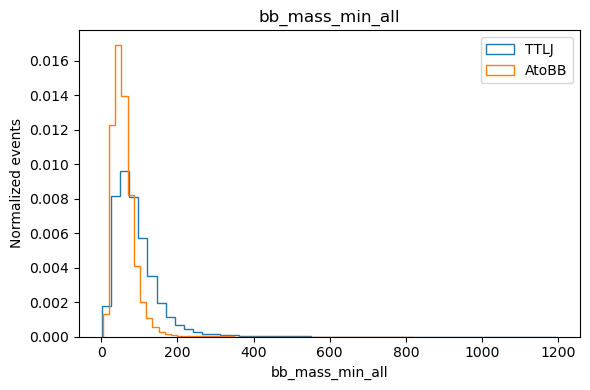

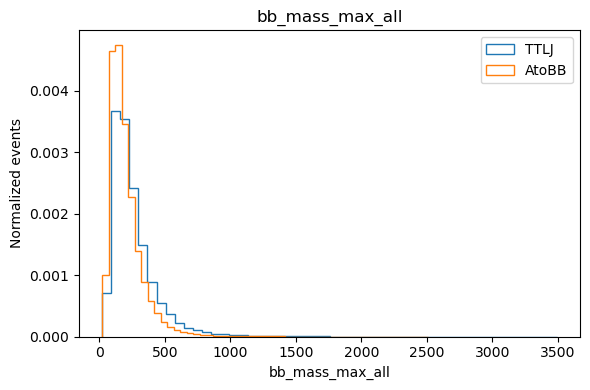

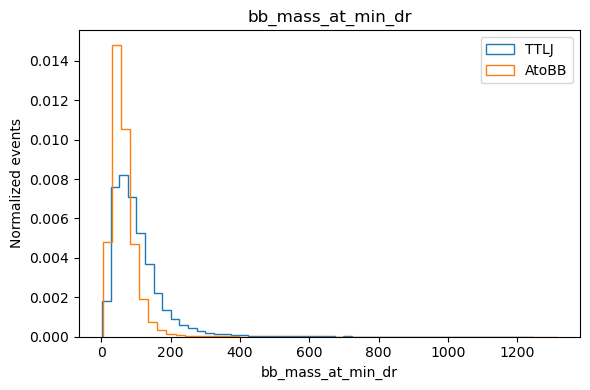

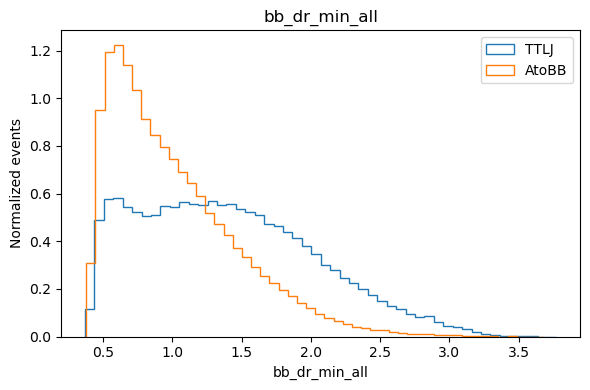

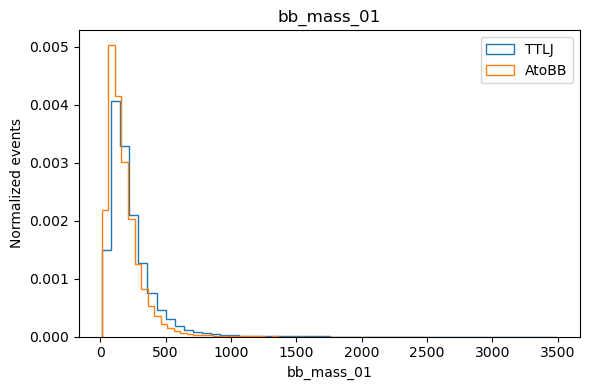

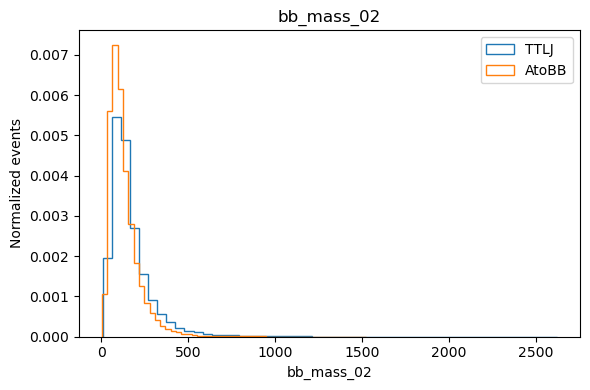

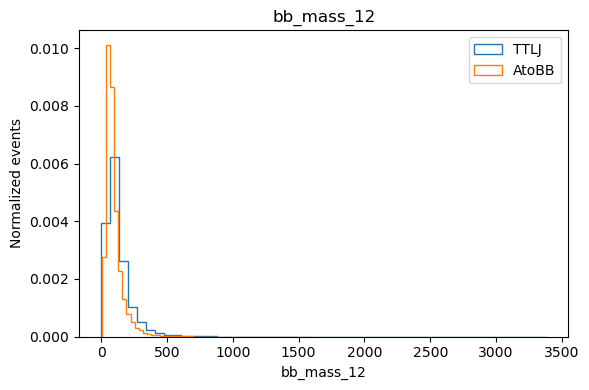

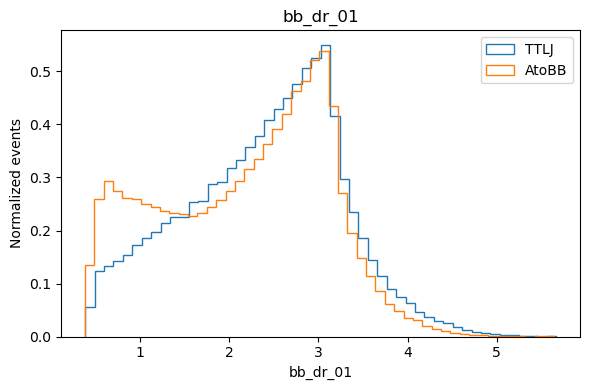

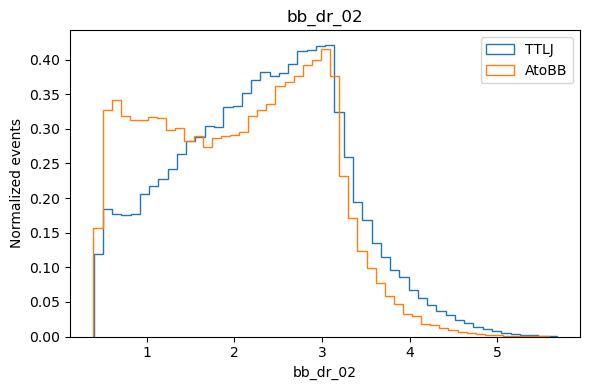

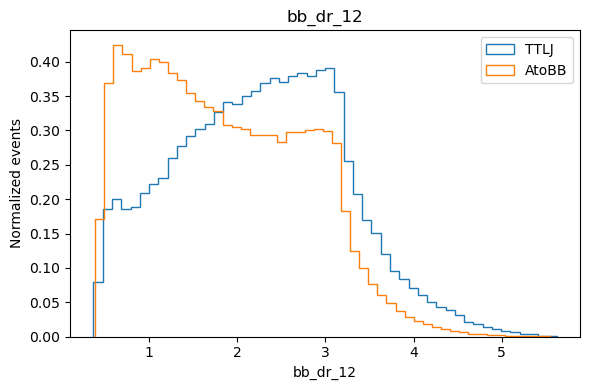

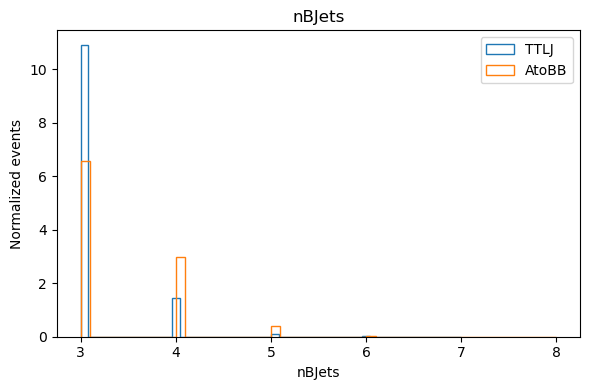

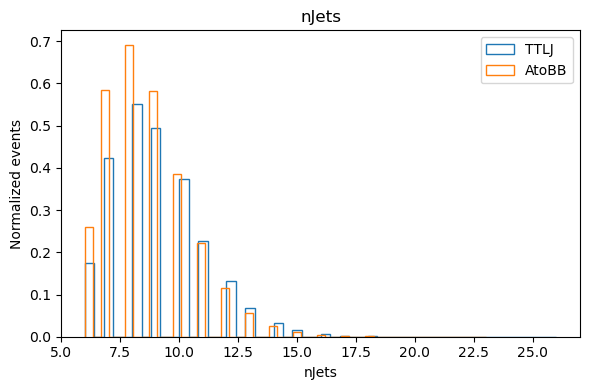

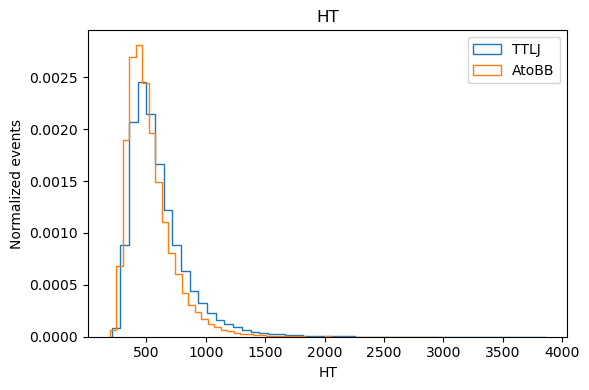

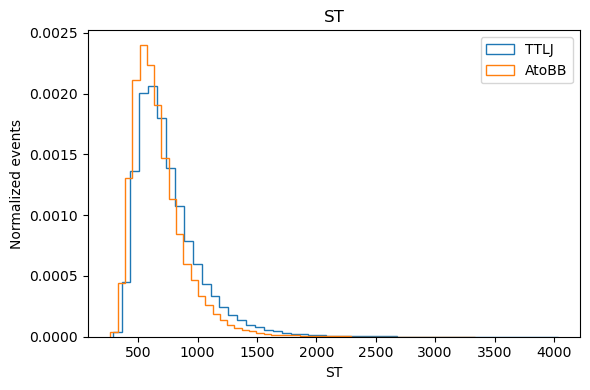

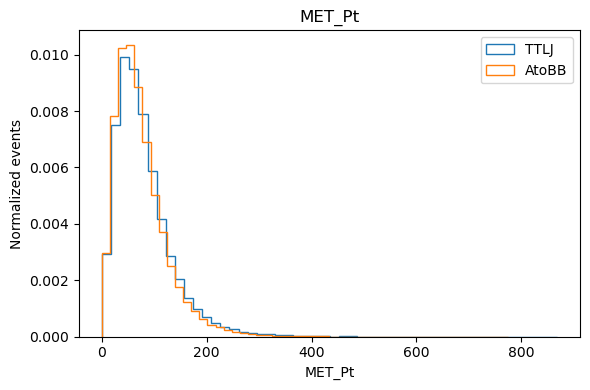

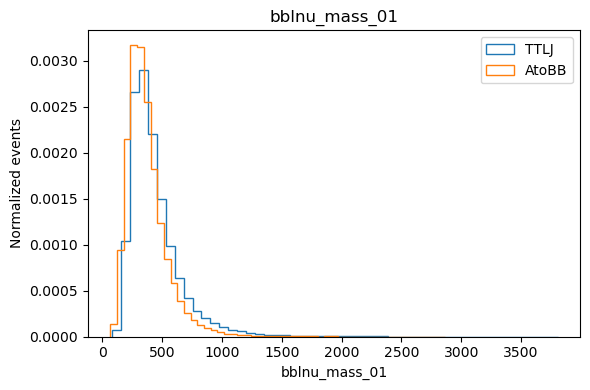

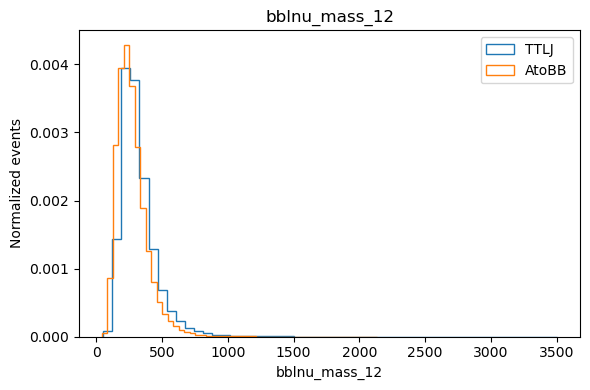

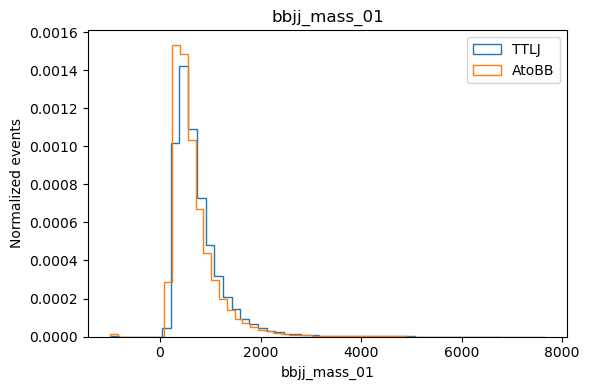

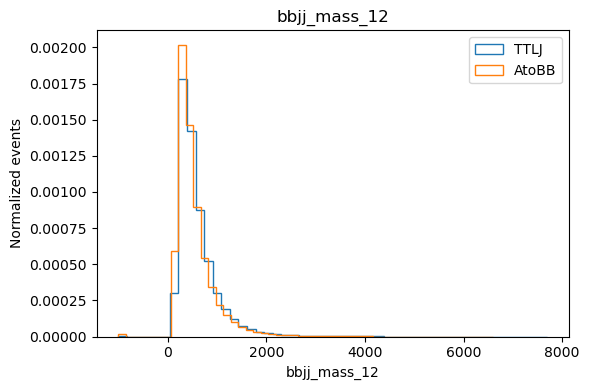

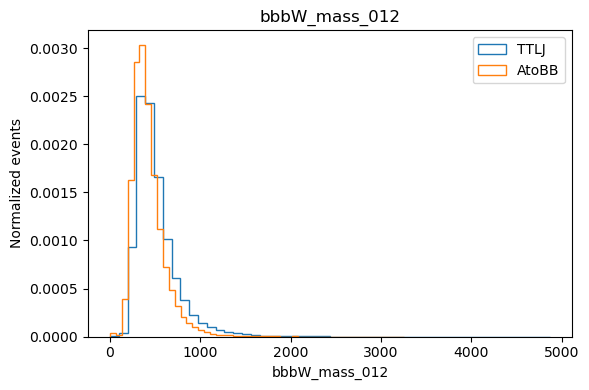

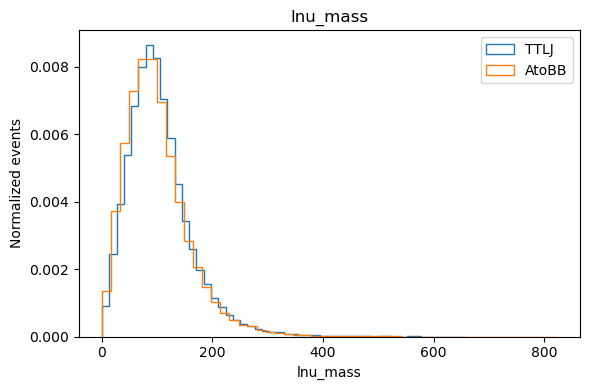

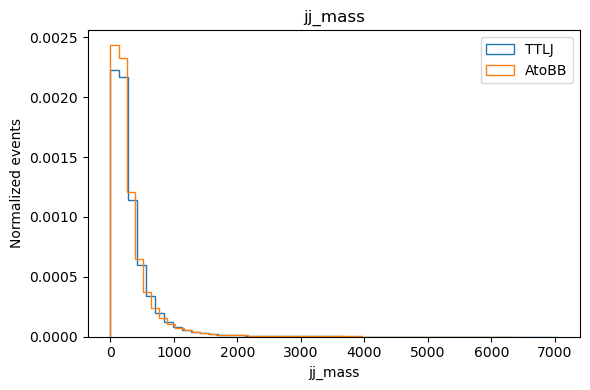

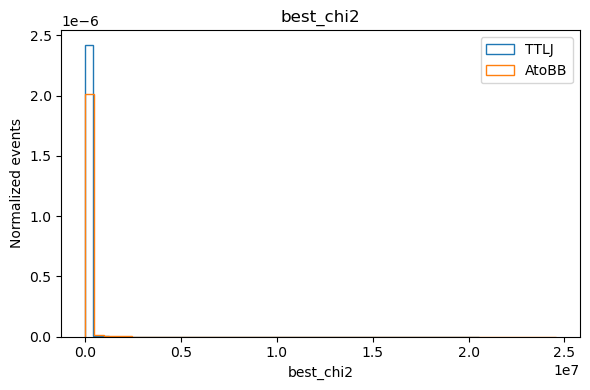

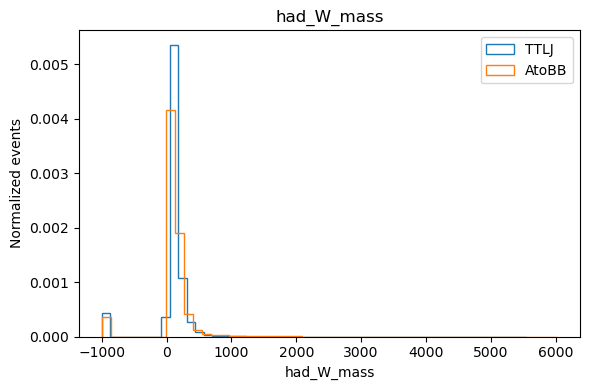

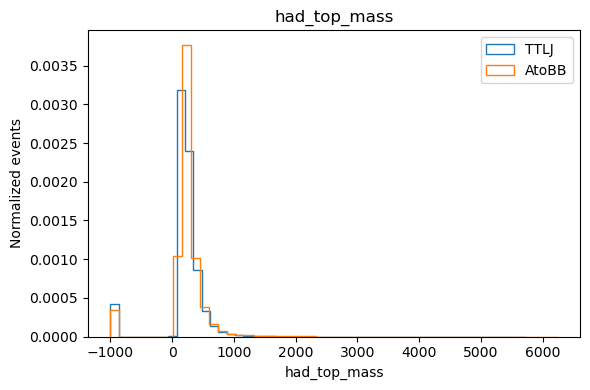

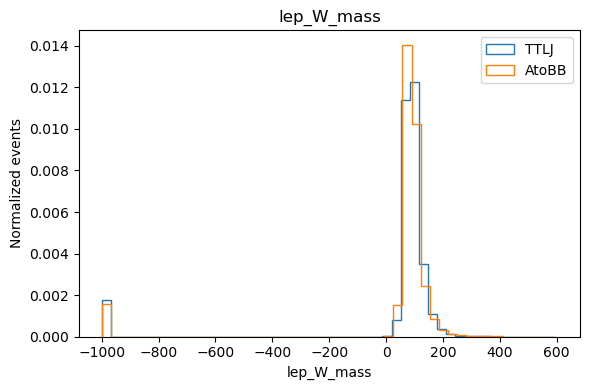

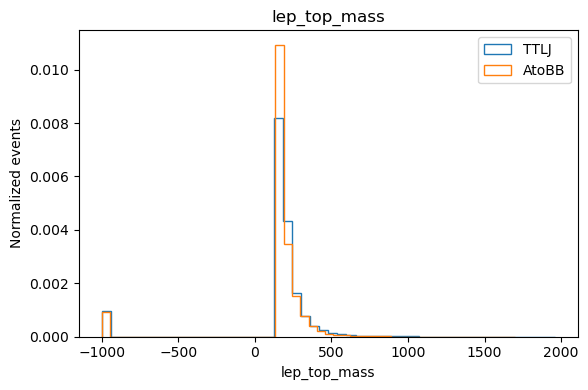

In [16]:
# ============================================================
# 9. Sanity plots before cleaning/training
# ============================================================

def plot_feature(sig, bkg, feature, bins=50, x_range=None, logy=False):
    plt.figure(figsize=(6, 4))
    plt.hist(bkg[feature].replace([np.inf, -np.inf], np.nan).dropna(), bins=bins, range=x_range, histtype="step", density=True, label="TTLJ")
    plt.hist(sig[feature].replace([np.inf, -np.inf], np.nan).dropna(), bins=bins, range=x_range, histtype="step", density=True, label="AtoBB")

    if logy:
        plt.yscale("log")

    plt.xlabel(feature)
    plt.ylabel("Normalized events")
    plt.title(feature)
    plt.legend()
    plt.tight_layout()
    plt.show()

PLOT_FEATURES = [
    # Restored summary features
    "bb_mass_min_all", "bb_mass_max_all", "bb_mass_at_min_dr", "bb_dr_min_all",

    # Direct bb inputs
    "bb_mass_01", "bb_mass_02", "bb_mass_12",
    "bb_dr_01", "bb_dr_02", "bb_dr_12",

    # Event topology
    "nBJets", "nJets", "HT", "ST", "MET_Pt",

    # Composite masses
    "bblnu_mass_01", "bblnu_mass_12",
    "bbjj_mass_01", "bbjj_mass_12",
    "bbbW_mass_012", 
    # "bW_mass_013",
    "lnu_mass", "jj_mass",

    # ttbar reconstruction
    "best_chi2", "had_W_mass", "had_top_mass", "lep_W_mass", "lep_top_mass",

    # "A_mass_best",
]

for feat in PLOT_FEATURES:
    plot_feature(df_sig, df_bkg, feat, bins=50)

In [17]:
from sklearn.metrics import roc_auc_score

all_auc = []

for feat in FEATURES:

    sig = df_sig_clean[feat].to_numpy(dtype=float)
    bkg = df_bkg_clean[feat].to_numpy(dtype=float)

    # ========================================================
    # [CHANGED]
    # XGBoost can train with NaN, but roc_auc_score cannot.
    # For this one-feature diagnostic only, remove non-finite
    # values feature-by-feature.
    # ========================================================
    sig = sig[np.isfinite(sig)]
    bkg = bkg[np.isfinite(bkg)]

    if len(sig) == 0 or len(bkg) == 0:
        print(f"[SKIP] {feat}: no finite signal/background values")
        continue

    y_true = np.concatenate([
        np.ones(len(sig)),
        np.zeros(len(bkg))
    ])

    score = np.concatenate([sig, bkg])

    auc = roc_auc_score(y_true, score)

    if auc < 0.5:
        auc = 1.0 - auc

    all_auc.append((feat, auc))

all_auc = sorted(all_auc, key=lambda x: x[1], reverse=True)

for feat, auc in all_auc:
    print(f"{feat:30s} {auc:.4f}")


bb_mass_min_all                0.6921
bb_mass_at_min_dr              0.6874
bb_dr_min_all                  0.6868
bb_mass_12                     0.6296
bbbW_mass_012                  0.6285
bb_dr_12                       0.6207
bb_mass_max_all                0.6189
bblnu_mass_12                  0.6119
nBJets                         0.6086
bb_mass_01                     0.6048
bblnu_mass_01                  0.6014
bb_mass_02                     0.6000
bblnu_mass_02                  0.5962
HT                             0.5962
ST                             0.5956
bb_dr_02                       0.5721
bbjj_mass_01                   0.5647
bbjj_mass_02                   0.5590
bb_dr_01                       0.5562
lep_top_mass                   0.5555
bbjj_mass_12                   0.5528
nJets                          0.5439
Lepton0_Pt                     0.5325
lnu_mass                       0.5280
MET_Pt                         0.5278
jj_mass                        0.5243
had_top_mass

## 8. Train / validation split

Use stratified split so both train and validation contain signal and background.


In [18]:
df_all = pd.concat(
    [df_sig_clean, df_bkg_clean],
    ignore_index=True,
)

df_all["split_group"] = np.where(
    df_all[LABEL_COL] == 1,
    "sig_MA" + df_all["mass_point"].astype(int).astype(str),
    "bkg",
)

train_df, val_df = train_test_split(
    df_all,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df_all["split_group"],
)

X_train = train_df[FEATURES].copy()
y_train = train_df[LABEL_COL].astype(int).copy()
w_train = train_df["ml_weight"].astype(float).copy()
# w_train = np.ones(len(train_df))

X_val = val_df[FEATURES].copy()
y_val = val_df[LABEL_COL].astype(int).copy()
w_val = val_df["ml_weight"].astype(float).copy()
# w_val = np.ones(len(val_df))

used_columns = list(X_train.columns)

if SCALER_TYPE == "standard":
    scaler = StandardScaler()
elif SCALER_TYPE == "minmax":
    scaler = MinMaxScaler()
elif SCALER_TYPE is None:
    scaler = None
else:
    raise ValueError(f"Unknown SCALER_TYPE = {SCALER_TYPE}")

if scaler is not None:
    X_train_np = scaler.fit_transform(X_train)
    X_val_np = scaler.transform(X_val)
else:
    X_train_np = X_train.to_numpy(dtype=np.float32)
    X_val_np = X_val.to_numpy(dtype=np.float32)

X_train = pd.DataFrame(X_train_np, columns=used_columns)
X_val = pd.DataFrame(X_val_np, columns=used_columns)

# ONNX/XGBoost conversion is safer with integer feature names.
X_train.columns = range(len(used_columns))
X_val.columns = range(len(used_columns))

print("Train label counts:")
print(y_train.value_counts())
print("Validation label counts:")
print(y_val.value_counts())
print("used columns:")
for i, c in enumerate(used_columns):
    print(f"  {i:02d}: {c}")




Train label counts:
label
1    92312
0    80000
Name: count, dtype: int64
Validation label counts:
label
1    23079
0    20000
Name: count, dtype: int64
used columns:
  00: HT
  01: ST
  02: MET_Pt
  03: nJets
  04: nBJets
  05: Lepton0_Pt
  06: Lepton0_Eta
  07: bb_mass_min_all
  08: bb_mass_max_all
  09: bb_mass_at_min_dr
  10: bb_dr_min_all
  11: bb_mass_01
  12: bb_mass_02
  13: bb_mass_12
  14: bb_dr_01
  15: bb_dr_02
  16: bb_dr_12
  17: bblnu_mass_01
  18: bblnu_mass_02
  19: bblnu_mass_12
  20: bbjj_mass_01
  21: bbjj_mass_02
  22: bbjj_mass_12
  23: bbbW_mass_012
  24: lnu_mass
  25: jj_mass
  26: best_chi2
  27: had_W_mass
  28: had_top_mass
  29: lep_W_mass
  30: lep_top_mass


## 9. Train XGBoost model

This is a first-pass model. Tune `max_depth`, `eta`, and `num_boost_round` later.


In [19]:
dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
dval = xgb.DMatrix(X_val, label=y_val, weight=w_val)

params = {
    "max_depth": 2,
    "eta": 0.05,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 20,
    # "lambda": 1.0,
    # "alpha": 0.5,
    "random_state": 42,
    "tree_method": "hist",
    # "scale_pos_weight": len(df_bkg_clean) / len(df_sig_clean)
}

evals_result = {}
model = xgb.train(
    params,
    dtrain,
    num_boost_round=NUM_BOOST_ROUND,
    evals=[(dtrain, "train"), (dval, "validation")],
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=50,
)

print("Finished training with num_boost_round =", NUM_BOOST_ROUND)
print("Final train logloss     =", evals_result["train"]["logloss"][-1])
print("Final validation logloss=", evals_result["validation"]["logloss"][-1])

[0]	train-logloss:0.68678	validation-logloss:0.68669
[50]	train-logloss:0.59422	validation-logloss:0.59197
[100]	train-logloss:0.57950	validation-logloss:0.57778
[150]	train-logloss:0.57209	validation-logloss:0.57083
[200]	train-logloss:0.56736	validation-logloss:0.56646
[250]	train-logloss:0.56405	validation-logloss:0.56345
[300]	train-logloss:0.56131	validation-logloss:0.56086
[350]	train-logloss:0.55916	validation-logloss:0.55900
[400]	train-logloss:0.55719	validation-logloss:0.55730
[450]	train-logloss:0.55543	validation-logloss:0.55587
[499]	train-logloss:0.55399	validation-logloss:0.55474
Finished training with num_boost_round = 500
Final train logloss     = 0.5539899506004257
Final validation logloss= 0.5547438932495471


===== Scan dataset =====
Train entries      : 172312
Validation entries : 43079
Train signal       : 92312
Train background   : 80000
Val signal         : 23079
Val background     : 20000

[1/6] max_depth=3, min_child_weight=10
    train AUC = 0.821042 | val AUC = 0.801588 | gap = 0.019453
    best iter = 1493 | val logloss = 0.540228
    KS sig p = 0.0735 | KS bkg p = 0.0013

[2/6] max_depth=3, min_child_weight=20
    train AUC = 0.820377 | val AUC = 0.801360 | gap = 0.019016
    best iter = 1495 | val logloss = 0.540486
    KS sig p = 0.0660 | KS bkg p = 0.0019

[3/6] max_depth=3, min_child_weight=30
    train AUC = 0.820010 | val AUC = 0.801530 | gap = 0.018480
    best iter = 1493 | val logloss = 0.540302
    KS sig p = 0.0770 | KS bkg p = 0.0037

[4/6] max_depth=4, min_child_weight=10
    train AUC = 0.838788 | val AUC = 0.803218 | gap = 0.035571
    best iter = 1252 | val logloss = 0.538518
    KS sig p = 0.0000 | KS bkg p = 0.0000

[5/6] max_depth=4, min_child_weight=20
    trai

,max_depth,min_child_weight,best_iteration,train_auc,val_auc,auc_gap,val_logloss,ks_sig_p,ks_bkg_p
0,4,30,1475,0.840888,0.803286,0.037603,0.538433,8.509162e-07,1.207384e-11
1,4,10,1252,0.838788,0.803218,0.035571,0.538518,8.555995e-06,1.245601e-09
2,4,20,1483,0.842508,0.802969,0.039539,0.538693,3.601924e-07,1.428959e-12
3,3,10,1493,0.821042,0.801588,0.019453,0.540228,7.347979e-02,1.278656e-03
4,3,30,1493,0.820010,0.801530,0.018480,0.540302,7.695696e-02,3.658101e-03
5,3,20,1495,0.820377,0.801360,0.019016,0.540486,6.600838e-02,1.897682e-03



BEST VALIDATION AUC
max_depth        = 4
min_child_weight = 30
best_iteration   = 1475
Train AUC        = 0.840888
Validation AUC   = 0.803286
AUC gap          = 0.037603
Signal KS p      = 0.000001
Background KS p  = 0.000000


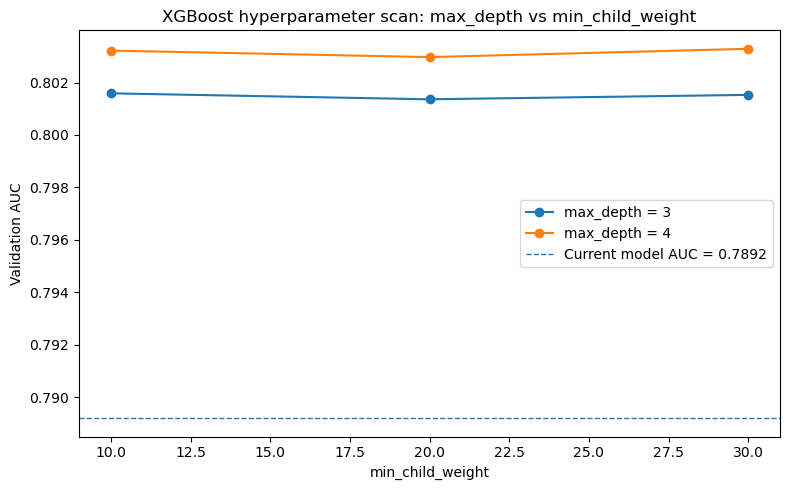

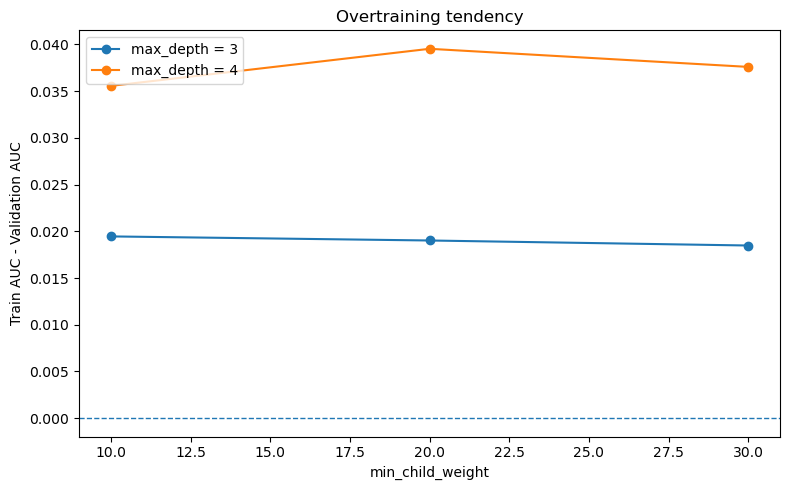

In [36]:
# ============================================================
# Hyperparameter scan: max_depth x min_child_weight
#
# Purpose:
#   Scan tree complexity / child-node regularization before
#   producing the final combined-MA ONNX model.
#
# Uses:
#   - the SAME df_sig_clean / df_bkg_clean
#   - the SAME FEATURES
#   - the SAME train/validation split strategy
#   - the SAME ml_weight
#
# Metrics:
#   - Train AUC
#   - Validation AUC
#   - AUC gap
#   - Train / validation logloss
#   - Signal / background KS test
#
# IMPORTANT:
#   This cell does NOT overwrite the final model or ONNX.
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt


# ============================================================
# 1. Scan configuration
# ============================================================

SCAN_MAX_DEPTH = [3, 4]
SCAN_MIN_CHILD_WEIGHT = [10, 20, 30]

SCAN_NUM_BOOST_ROUND = 1500
SCAN_EARLY_STOPPING_ROUNDS = 80
SCAN_RANDOM_SEED = 42


# ============================================================
# 2. Build exactly one common train / validation split
#
# IMPORTANT:
# Every hyperparameter combination must see the SAME events.
# Otherwise the comparison is not fair.
# ============================================================

scan_all = pd.concat(
    [df_sig_clean, df_bkg_clean],
    ignore_index=True,
)

scan_train, scan_val = train_test_split(
    scan_all,
    test_size=0.20,
    random_state=SCAN_RANDOM_SEED,
    stratify=scan_all[LABEL_COL],
)


# ============================================================
# 3. Prepare X / y / weights
#
# No scaler is used because the final XGBoost model uses
# SCALER_TYPE = None.
#
# Keep feature names here so the scan matches the final model.
# ============================================================

X_train_scan = scan_train[FEATURES].astype(float)
X_val_scan = scan_val[FEATURES].astype(float)

y_train_scan = scan_train[LABEL_COL].astype(int).to_numpy()
y_val_scan = scan_val[LABEL_COL].astype(int).to_numpy()

w_train_scan = scan_train["ml_weight"].astype(float).to_numpy()
w_val_scan = scan_val["ml_weight"].astype(float).to_numpy()

dtrain_scan = xgb.DMatrix(
    X_train_scan,
    label=y_train_scan,
    weight=w_train_scan,
    feature_names=FEATURES,
)

dval_scan = xgb.DMatrix(
    X_val_scan,
    label=y_val_scan,
    weight=w_val_scan,
    feature_names=FEATURES,
)


print("===== Scan dataset =====")
print(f"Train entries      : {len(scan_train)}")
print(f"Validation entries : {len(scan_val)}")
print(f"Train signal       : {(y_train_scan == 1).sum()}")
print(f"Train background   : {(y_train_scan == 0).sum()}")
print(f"Val signal         : {(y_val_scan == 1).sum()}")
print(f"Val background     : {(y_val_scan == 0).sum()}")
print()


# ============================================================
# 4. Scan
# ============================================================

scan_results = []

total_jobs = (
    len(SCAN_MAX_DEPTH)
    * len(SCAN_MIN_CHILD_WEIGHT)
)

job = 0

for max_depth in SCAN_MAX_DEPTH:
    for min_child_weight in SCAN_MIN_CHILD_WEIGHT:

        job += 1

        print(
            f"[{job}/{total_jobs}] "
            f"max_depth={max_depth}, "
            f"min_child_weight={min_child_weight}"
        )

        # ----------------------------------------------------
        # Start from the SAME parameters as the final model.
        # Only the two parameters being scanned are changed.
        # ----------------------------------------------------

        scan_params = params.copy()

        scan_params["max_depth"] = max_depth
        scan_params["min_child_weight"] = min_child_weight
        scan_params["random_state"] = SCAN_RANDOM_SEED
        scan_params["eval_metric"] = "logloss"


        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        evals_result = {}

        model_scan = xgb.train(
            scan_params,
            dtrain_scan,
            num_boost_round=SCAN_NUM_BOOST_ROUND,
            evals=[
                (dtrain_scan, "train"),
                (dval_scan, "validation"),
            ],
            evals_result=evals_result,
            early_stopping_rounds=SCAN_EARLY_STOPPING_ROUNDS,
            verbose_eval=False,
        )


        # ----------------------------------------------------
        # Best iteration
        # ----------------------------------------------------

        if hasattr(model_scan, "best_iteration"):
            best_iteration = model_scan.best_iteration
        else:
            best_iteration = (
                model_scan.num_boosted_rounds() - 1
            )


        # ----------------------------------------------------
        # Prediction
        #
        # Use trees only up to best_iteration.
        # ----------------------------------------------------

        iteration_range = (
            0,
            best_iteration + 1,
        )

        pred_train = model_scan.predict(
            dtrain_scan,
            iteration_range=iteration_range,
        )

        pred_val = model_scan.predict(
            dval_scan,
            iteration_range=iteration_range,
        )


        # ====================================================
        # 5. Weighted AUC
        # ====================================================

        train_auc = roc_auc_score(
            y_train_scan,
            pred_train,
            sample_weight=w_train_scan,
        )

        val_auc = roc_auc_score(
            y_val_scan,
            pred_val,
            sample_weight=w_val_scan,
        )

        auc_gap = train_auc - val_auc


        # ====================================================
        # 6. Logloss at best iteration
        # ====================================================

        train_logloss = evals_result[
            "train"
        ]["logloss"][best_iteration]

        val_logloss = evals_result[
            "validation"
        ]["logloss"][best_iteration]


        # ====================================================
        # 7. KS overtraining test
        #
        # Same convention as the existing notebook:
        # unweighted scipy KS test.
        # ====================================================

        train_sig_score = pred_train[
            y_train_scan == 1
        ]

        val_sig_score = pred_val[
            y_val_scan == 1
        ]

        train_bkg_score = pred_train[
            y_train_scan == 0
        ]

        val_bkg_score = pred_val[
            y_val_scan == 0
        ]


        ks_sig = ks_2samp(
            train_sig_score,
            val_sig_score,
        )

        ks_bkg = ks_2samp(
            train_bkg_score,
            val_bkg_score,
        )


        # ====================================================
        # 8. Store
        # ====================================================

        scan_results.append({
            "max_depth": max_depth,
            "min_child_weight": min_child_weight,
            "best_iteration": best_iteration,
            "train_auc": train_auc,
            "val_auc": val_auc,
            "auc_gap": auc_gap,
            "train_logloss": train_logloss,
            "val_logloss": val_logloss,
            "ks_sig_D": ks_sig.statistic,
            "ks_sig_p": ks_sig.pvalue,
            "ks_bkg_D": ks_bkg.statistic,
            "ks_bkg_p": ks_bkg.pvalue,
        })

        print(
            f"    train AUC = {train_auc:.6f} | "
            f"val AUC = {val_auc:.6f} | "
            f"gap = {auc_gap:.6f}"
        )

        print(
            f"    best iter = {best_iteration} | "
            f"val logloss = {val_logloss:.6f}"
        )

        print(
            f"    KS sig p = {ks_sig.pvalue:.4f} | "
            f"KS bkg p = {ks_bkg.pvalue:.4f}"
        )

        print()


# ============================================================
# 9. Results table
# ============================================================

scan_df = pd.DataFrame(scan_results)

scan_df = scan_df.sort_values(
    by="val_auc",
    ascending=False,
).reset_index(drop=True)


print("============================================================")
print("SCAN RESULTS — sorted by validation AUC")
print("============================================================")

display(
    scan_df[
        [
            "max_depth",
            "min_child_weight",
            "best_iteration",
            "train_auc",
            "val_auc",
            "auc_gap",
            "val_logloss",
            "ks_sig_p",
            "ks_bkg_p",
        ]
    ]
)


# ============================================================
# 10. Best validation-AUC point
# ============================================================

best = scan_df.iloc[0]

print()
print("============================================================")
print("BEST VALIDATION AUC")
print("============================================================")

print(
    f"max_depth        = "
    f"{int(best['max_depth'])}"
)

print(
    f"min_child_weight = "
    f"{int(best['min_child_weight'])}"
)

print(
    f"best_iteration   = "
    f"{int(best['best_iteration'])}"
)

print(
    f"Train AUC        = "
    f"{best['train_auc']:.6f}"
)

print(
    f"Validation AUC   = "
    f"{best['val_auc']:.6f}"
)

print(
    f"AUC gap          = "
    f"{best['auc_gap']:.6f}"
)

print(
    f"Signal KS p      = "
    f"{best['ks_sig_p']:.6f}"
)

print(
    f"Background KS p  = "
    f"{best['ks_bkg_p']:.6f}"
)


# ============================================================
# 11. Plot: validation AUC
# ============================================================

plt.figure(figsize=(8, 5))

for depth in SCAN_MAX_DEPTH:

    temp = (
        scan_df[
            scan_df["max_depth"] == depth
        ]
        .sort_values("min_child_weight")
    )

    plt.plot(
        temp["min_child_weight"],
        temp["val_auc"],
        marker="o",
        label=f"max_depth = {depth}",
    )

plt.axhline(
    0.7892074689,
    linestyle="--",
    linewidth=1,
    label="Current model AUC = 0.7892",
)

plt.xlabel("min_child_weight")
plt.ylabel("Validation AUC")
plt.title(
    "XGBoost hyperparameter scan: "
    "max_depth vs min_child_weight"
)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 12. Plot: AUC gap
#
# Smaller is generally safer, but do NOT optimize only for gap.
# A model with low train and low validation AUC can also have
# a tiny gap.
# ============================================================

plt.figure(figsize=(8, 5))

for depth in SCAN_MAX_DEPTH:

    temp = (
        scan_df[
            scan_df["max_depth"] == depth
        ]
        .sort_values("min_child_weight")
    )

    plt.plot(
        temp["min_child_weight"],
        temp["auc_gap"],
        marker="o",
        label=f"max_depth = {depth}",
    )

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel("min_child_weight")
plt.ylabel("Train AUC - Validation AUC")
plt.title("Overtraining tendency")

plt.legend()
plt.tight_layout()
plt.show()


In [38]:
# ------------------------------------------------------------
# Get labels / weights directly from DMatrix
# -> avoids dependency on notebook variable names
# ------------------------------------------------------------

ytr = dtrain.get_label()
yva = dval.get_label()

wtr = dtrain.get_weight()
wva = dval.get_weight()

print("Train:")
print("  N =", len(ytr))
print("  signal =", np.sum(ytr == 1))
print("  bkg    =", np.sum(ytr == 0))
print("  weight sum =", np.sum(wtr))

print()

print("Validation:")
print("  N =", len(yva))
print("  signal =", np.sum(yva == 1))
print("  bkg    =", np.sum(yva == 0))
print("  weight sum =", np.sum(wva))

Train:
  N = 172312
  signal = 92312
  bkg    = 80000
  weight sum = 172274.23

Validation:
  N = 43079
  signal = 23079
  bkg    = 20000
  weight sum = 43116.77



Checking max_depth=3, min_child_weight=30
Best iteration : 1493
Train AUC      : 0.820010
Validation AUC : 0.801530
AUC gap        : 0.018480
Signal KS      : D=0.00938, p=0.07696
Background KS  : D=0.01402, p=0.00366


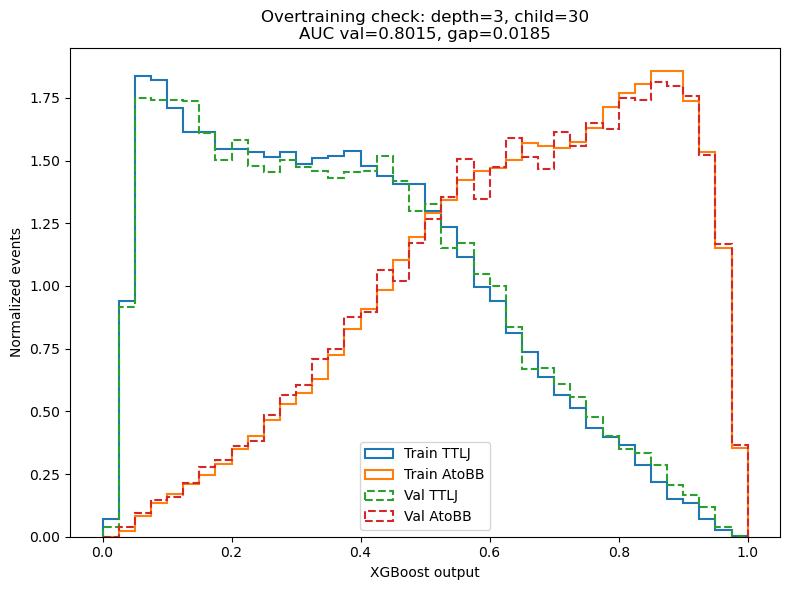

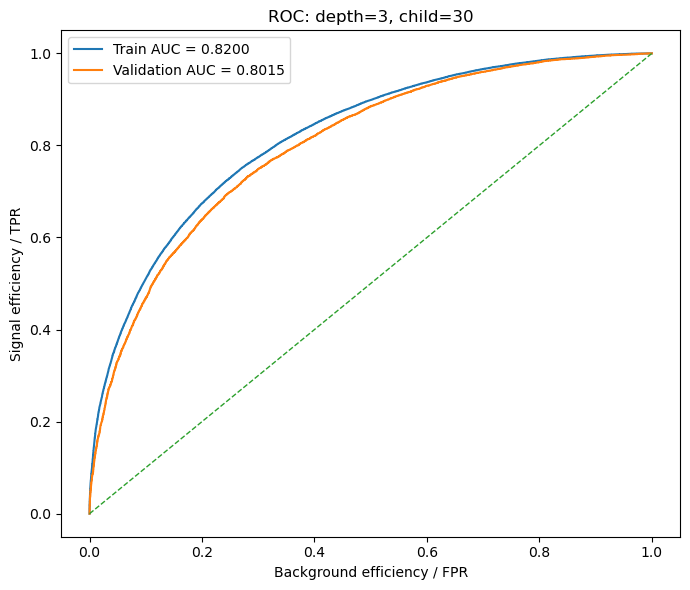

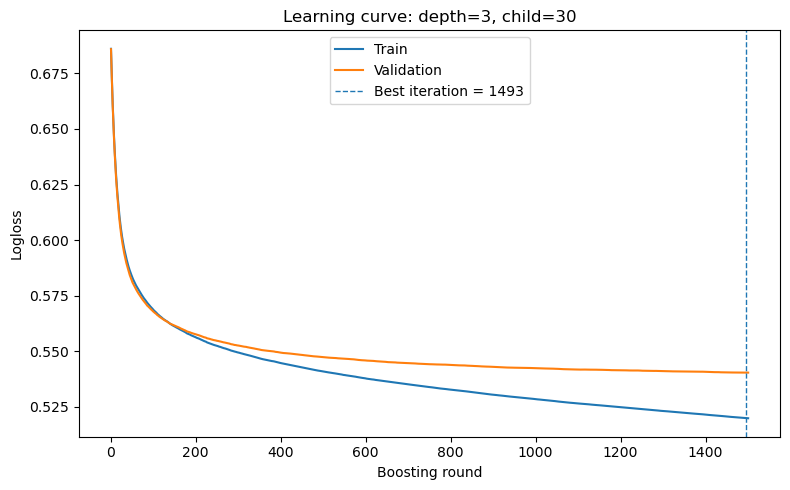


Checking max_depth=4, min_child_weight=10
Best iteration : 1252
Train AUC      : 0.838788
Validation AUC : 0.803218
AUC gap        : 0.035571
Signal KS      : D=0.01829, p=0.00001
Background KS  : D=0.02572, p=0.00000


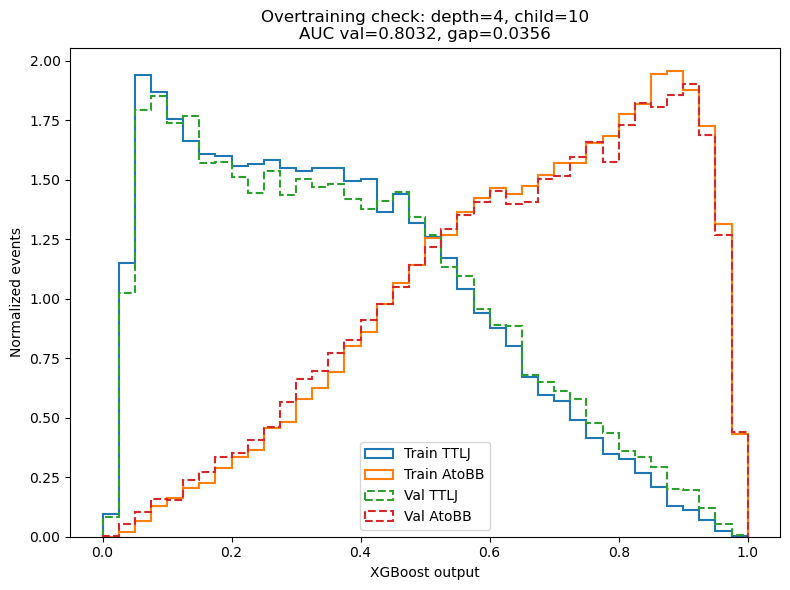

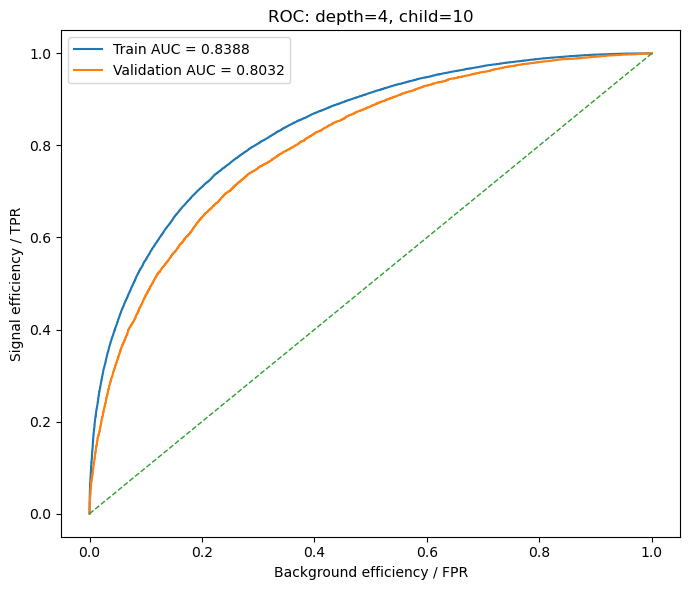

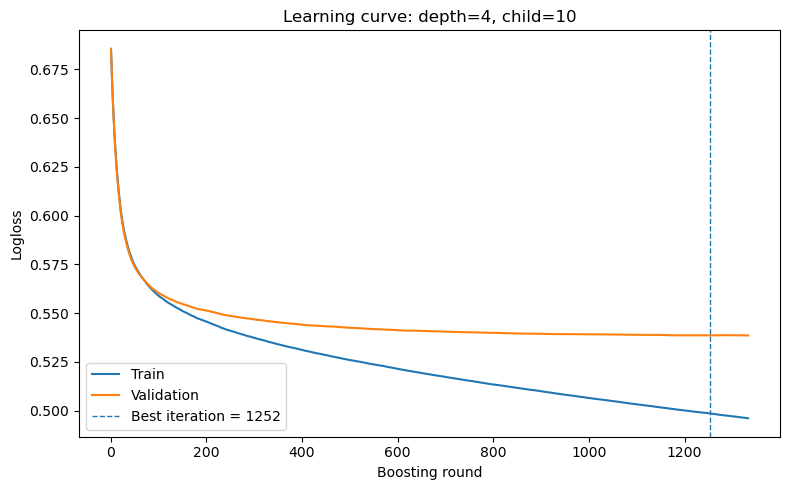


Checking max_depth=4, min_child_weight=30
Best iteration : 1475
Train AUC      : 0.840888
Validation AUC : 0.803286
AUC gap        : 0.037603
Signal KS      : D=0.01992, p=0.00000
Background KS  : D=0.02840, p=0.00000


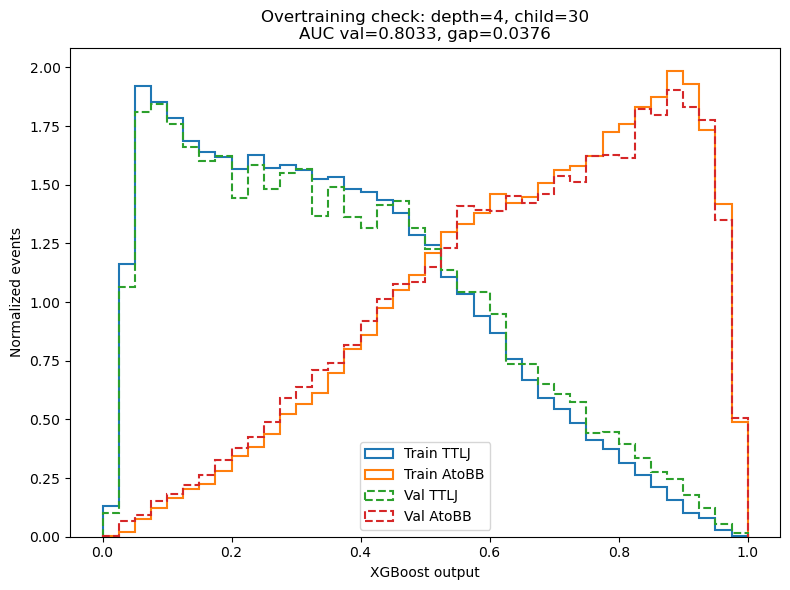

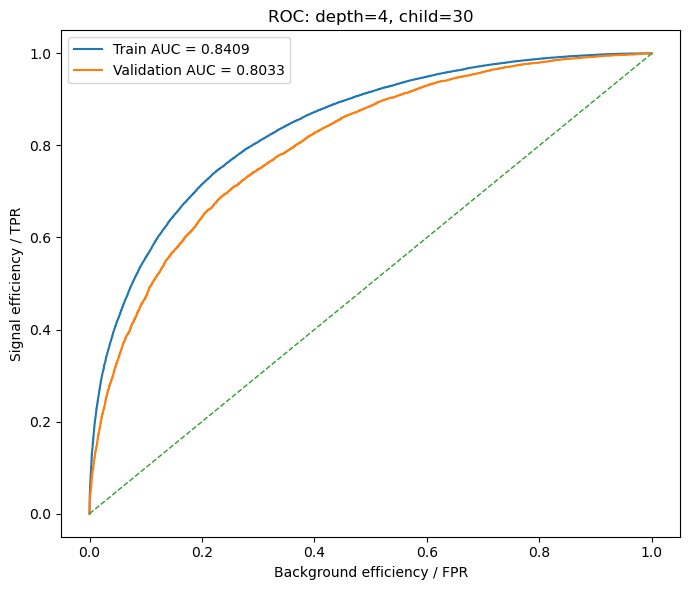

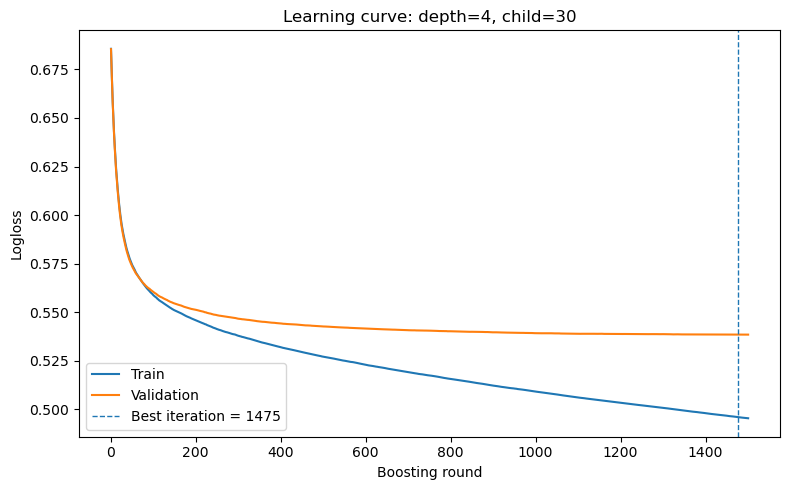


OVERTRAINING CANDIDATE SUMMARY


,max_depth,min_child_weight,best_iteration,train_auc,val_auc,auc_gap,ks_sig_D,ks_sig_p,ks_bkg_D,ks_bkg_p
0,4,30,1475,0.840888,0.803286,0.037603,0.019922,8.509162e-07,0.028400,1.207384e-11
1,4,10,1252,0.838788,0.803218,0.035571,0.018287,8.555995e-06,0.025725,1.245601e-09
2,3,30,1493,0.820010,0.801530,0.018480,0.009383,7.695696e-02,0.014025,3.658101e-03


Saved: hyperparameter_scan/overtraining/overtraining_candidate_summary.csv


In [39]:
# ============================================================
# Detailed overtraining check for selected scan candidates
#
# Run AFTER the hyperparameter scan cell.
#
# Produces for each selected configuration:
#   1. Train vs validation BDT-score distribution
#   2. Train vs validation ROC
#   3. Learning curve (logloss)
#   4. KS statistics
#
# PNG + PDF are both saved.
# ============================================================

from pathlib import Path
from scipy.stats import ks_2samp
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb


# ============================================================
# 1. Candidate configurations
#
# Edit this after looking at scan_df.
# ============================================================

OVERTRAIN_CANDIDATES = [
    {"max_depth": 3, "min_child_weight": 30},
    {"max_depth": 4, "min_child_weight": 10},
    {"max_depth": 4, "min_child_weight": 30},
]

CHECK_NUM_BOOST_ROUND = 1500
CHECK_EARLY_STOPPING_ROUNDS = 80


# ============================================================
# 2. Output directory
# ============================================================

OVERTRAIN_DIR = Path("./hyperparameter_scan/overtraining")
OVERTRAIN_PDF_DIR = OVERTRAIN_DIR / "pdf"

OVERTRAIN_DIR.mkdir(parents=True, exist_ok=True)
OVERTRAIN_PDF_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 3. Re-train selected candidates on the SAME split
#
# Uses:
#   dtrain_scan
#   dval_scan
#   y_train_scan
#   y_val_scan
#   w_train_scan
#   w_val_scan
#
# from the previous scan cell.
# ============================================================

overtrain_summary = []

for cfg in OVERTRAIN_CANDIDATES:

    depth = cfg["max_depth"]
    child = cfg["min_child_weight"]

    print()
    print("============================================================")
    print(
        f"Checking max_depth={depth}, "
        f"min_child_weight={child}"
    )
    print("============================================================")

    check_params = params.copy()

    check_params["max_depth"] = depth
    check_params["min_child_weight"] = child
    check_params["random_state"] = 42
    check_params["eval_metric"] = "logloss"


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    evals_result = {}

    model_check = xgb.train(
        check_params,
        dtrain_scan,
        num_boost_round=CHECK_NUM_BOOST_ROUND,
        evals=[
            (dtrain_scan, "train"),
            (dval_scan, "validation"),
        ],
        evals_result=evals_result,
        early_stopping_rounds=CHECK_EARLY_STOPPING_ROUNDS,
        verbose_eval=False,
    )


    # --------------------------------------------------------
    # Best iteration
    # --------------------------------------------------------

    best_iteration = model_check.best_iteration

    iteration_range = (
        0,
        best_iteration + 1,
    )


    # --------------------------------------------------------
    # Predictions at BEST iteration
    # --------------------------------------------------------

    pred_train = model_check.predict(
        dtrain_scan,
        iteration_range=iteration_range,
    )

    pred_val = model_check.predict(
        dval_scan,
        iteration_range=iteration_range,
    )


    # ========================================================
    # Metrics
    # ========================================================

    train_auc = roc_auc_score(
        y_train_scan,
        pred_train,
        sample_weight=w_train_scan,
    )

    val_auc = roc_auc_score(
        y_val_scan,
        pred_val,
        sample_weight=w_val_scan,
    )

    auc_gap = train_auc - val_auc


    # --------------------------------------------------------
    # KS
    # --------------------------------------------------------

    train_sig = pred_train[
        y_train_scan == 1
    ]

    val_sig = pred_val[
        y_val_scan == 1
    ]

    train_bkg = pred_train[
        y_train_scan == 0
    ]

    val_bkg = pred_val[
        y_val_scan == 0
    ]

    ks_sig = ks_2samp(
        train_sig,
        val_sig,
    )

    ks_bkg = ks_2samp(
        train_bkg,
        val_bkg,
    )


    print(
        f"Best iteration : {best_iteration}"
    )

    print(
        f"Train AUC      : {train_auc:.6f}"
    )

    print(
        f"Validation AUC : {val_auc:.6f}"
    )

    print(
        f"AUC gap        : {auc_gap:.6f}"
    )

    print(
        f"Signal KS      : "
        f"D={ks_sig.statistic:.5f}, "
        f"p={ks_sig.pvalue:.5f}"
    )

    print(
        f"Background KS  : "
        f"D={ks_bkg.statistic:.5f}, "
        f"p={ks_bkg.pvalue:.5f}"
    )


    # ========================================================
    # 4. Overtraining score plot
    # ========================================================

    bins = np.linspace(
        0.0,
        1.0,
        41,
    )

    plt.figure(
        figsize=(8, 6)
    )

    plt.hist(
        train_bkg,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=1.5,
        label="Train TTLJ",
    )

    plt.hist(
        train_sig,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=1.5,
        label="Train AtoBB",
    )

    plt.hist(
        val_bkg,
        bins=bins,
        density=True,
        histtype="step",
        linestyle="--",
        linewidth=1.5,
        label="Val TTLJ",
    )

    plt.hist(
        val_sig,
        bins=bins,
        density=True,
        histtype="step",
        linestyle="--",
        linewidth=1.5,
        label="Val AtoBB",
    )

    plt.xlabel("XGBoost output")
    plt.ylabel("Normalized events")

    plt.title(
        f"Overtraining check: "
        f"depth={depth}, child={child}\n"
        f"AUC val={val_auc:.4f}, "
        f"gap={auc_gap:.4f}"
    )

    plt.legend()
    plt.tight_layout()

    tag = (
        f"depth{depth}_"
        f"child{child}"
    )

    over_png = (
        OVERTRAIN_DIR
        / f"overtraining_{tag}.png"
    )

    over_pdf = (
        OVERTRAIN_PDF_DIR
        / f"overtraining_{tag}.pdf"
    )

    plt.savefig(
        over_png,
        dpi=180,
        bbox_inches="tight",
    )

    plt.savefig(
        over_pdf,
        bbox_inches="tight",
    )

    plt.show()


    # ========================================================
    # 5. ROC: train vs validation
    # ========================================================

    fpr_train, tpr_train, _ = roc_curve(
        y_train_scan,
        pred_train,
        sample_weight=w_train_scan,
    )

    fpr_val, tpr_val, _ = roc_curve(
        y_val_scan,
        pred_val,
        sample_weight=w_val_scan,
    )

    plt.figure(
        figsize=(7, 6)
    )

    plt.plot(
        fpr_train,
        tpr_train,
        label=(
            f"Train AUC = "
            f"{train_auc:.4f}"
        ),
    )

    plt.plot(
        fpr_val,
        tpr_val,
        label=(
            f"Validation AUC = "
            f"{val_auc:.4f}"
        ),
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
    )

    plt.xlabel(
        "Background efficiency / FPR"
    )

    plt.ylabel(
        "Signal efficiency / TPR"
    )

    plt.title(
        f"ROC: depth={depth}, "
        f"child={child}"
    )

    plt.legend()
    plt.tight_layout()

    roc_png = (
        OVERTRAIN_DIR
        / f"roc_{tag}.png"
    )

    roc_pdf = (
        OVERTRAIN_PDF_DIR
        / f"roc_{tag}.pdf"
    )

    plt.savefig(
        roc_png,
        dpi=180,
        bbox_inches="tight",
    )

    plt.savefig(
        roc_pdf,
        bbox_inches="tight",
    )

    plt.show()


    # ========================================================
    # 6. Learning curve
    # ========================================================

    train_loss = (
        evals_result["train"]["logloss"]
    )

    val_loss = (
        evals_result["validation"]["logloss"]
    )

    rounds = np.arange(
        1,
        len(train_loss) + 1,
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        rounds,
        train_loss,
        label="Train",
    )

    plt.plot(
        rounds,
        val_loss,
        label="Validation",
    )

    plt.axvline(
        best_iteration + 1,
        linestyle="--",
        linewidth=1,
        label=(
            f"Best iteration = "
            f"{best_iteration}"
        ),
    )

    plt.xlabel(
        "Boosting round"
    )

    plt.ylabel(
        "Logloss"
    )

    plt.title(
        f"Learning curve: "
        f"depth={depth}, child={child}"
    )

    plt.legend()
    plt.tight_layout()

    learning_png = (
        OVERTRAIN_DIR
        / f"learning_curve_{tag}.png"
    )

    learning_pdf = (
        OVERTRAIN_PDF_DIR
        / f"learning_curve_{tag}.pdf"
    )

    plt.savefig(
        learning_png,
        dpi=180,
        bbox_inches="tight",
    )

    plt.savefig(
        learning_pdf,
        bbox_inches="tight",
    )

    plt.show()


    # ========================================================
    # 7. Store summary
    # ========================================================

    overtrain_summary.append({
        "max_depth": depth,
        "min_child_weight": child,
        "best_iteration": best_iteration,
        "train_auc": train_auc,
        "val_auc": val_auc,
        "auc_gap": auc_gap,
        "ks_sig_D": ks_sig.statistic,
        "ks_sig_p": ks_sig.pvalue,
        "ks_bkg_D": ks_bkg.statistic,
        "ks_bkg_p": ks_bkg.pvalue,
    })


# ============================================================
# 8. Candidate comparison table
# ============================================================

overtrain_df = pd.DataFrame(
    overtrain_summary
)

overtrain_df = (
    overtrain_df
    .sort_values(
        "val_auc",
        ascending=False,
    )
    .reset_index(drop=True)
)

print()
print("============================================================")
print("OVERTRAINING CANDIDATE SUMMARY")
print("============================================================")

display(overtrain_df)


# ============================================================
# 9. Save table
# ============================================================

summary_path = (
    OVERTRAIN_DIR
    / "overtraining_candidate_summary.csv"
)

overtrain_df.to_csv(
    summary_path,
    index=False,
)

print("Saved:", summary_path)


Scanning max_depth=3, min_child_weight=10
child=10 round= 300 | train=0.794077 val=0.791535 gap=0.002543 | KS(sig)=0.9277 KS(bkg)=0.9229
child=10 round= 500 | train=0.801722 val=0.796379 gap=0.005343 | KS(sig)=0.8775 KS(bkg)=0.7902
child=10 round= 700 | train=0.807106 val=0.798876 gap=0.008230 | KS(sig)=0.5892 KS(bkg)=0.3453
child=10 round= 900 | train=0.811248 val=0.800390 gap=0.010858 | KS(sig)=0.3089 KS(bkg)=0.1158
child=10 round=1100 | train=0.814827 val=0.801560 gap=0.013267 | KS(sig)=0.1553 KS(bkg)=0.02461
child=10 round=1300 | train=0.818000 val=0.802214 gap=0.015786 | KS(sig)=0.0662 KS(bkg)=0.005687
child=10 round=1500 | train=0.820917 val=0.802619 gap=0.018298 | KS(sig)=0.02939 KS(bkg)=0.002263

Scanning max_depth=3, min_child_weight=20
child=20 round= 300 | train=0.793875 val=0.791639 gap=0.002236 | KS(sig)=0.9539 KS(bkg)=0.9406
child=20 round= 500 | train=0.801516 val=0.796481 gap=0.005035 | KS(sig)=0.9458 KS(bkg)=0.8214
child=20 round= 700 | train=0.806787 val=0.799068 gap

,max_depth,min_child_weight,num_boost_round,train_auc,val_auc,auc_gap,ks_sig_D,ks_sig_p,ks_bkg_D,ks_bkg_p
13,3,20,1500,0.820343,0.802839,0.017504,0.009743,0.059678,0.015125,0.001310
20,3,30,1500,0.819637,0.802800,0.016837,0.009961,0.050915,0.014188,0.003159
6,3,10,1500,0.820917,0.802619,0.018298,0.010682,0.029389,0.014550,0.002263
12,3,20,1300,0.817485,0.802393,0.015091,0.008710,0.120695,0.013313,0.006826
5,3,10,1300,0.818000,0.802214,0.015786,0.009598,0.066200,0.013525,0.005687
19,3,30,1300,0.816844,0.802181,0.014663,0.009679,0.062482,0.012875,0.009852
11,3,20,1100,0.814348,0.801666,0.012683,0.008548,0.133853,0.010775,0.048349
4,3,10,1100,0.814827,0.801560,0.013267,0.008310,0.155259,0.011713,0.024611
18,3,30,1100,0.813723,0.801550,0.012173,0.008136,0.172558,0.010587,0.054967
10,3,20,900,0.810870,0.800581,0.010289,0.006577,0.399850,0.009325,0.122960


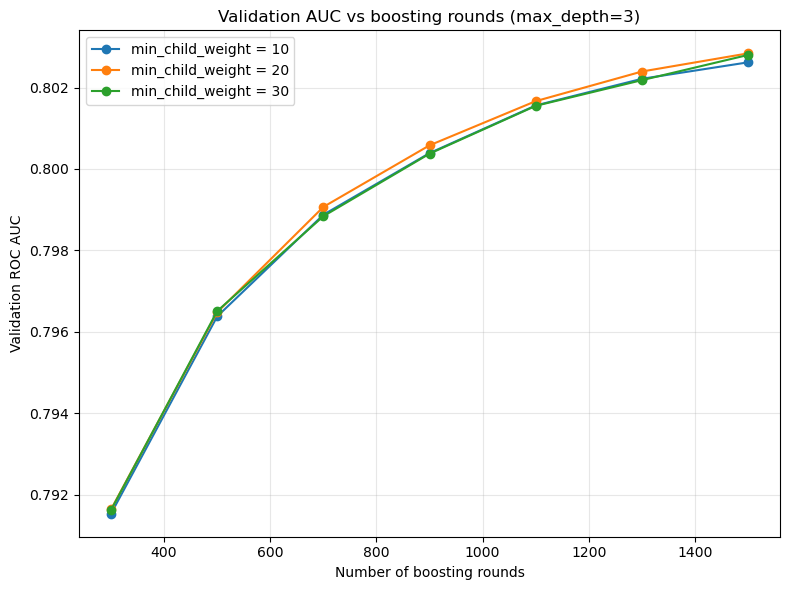

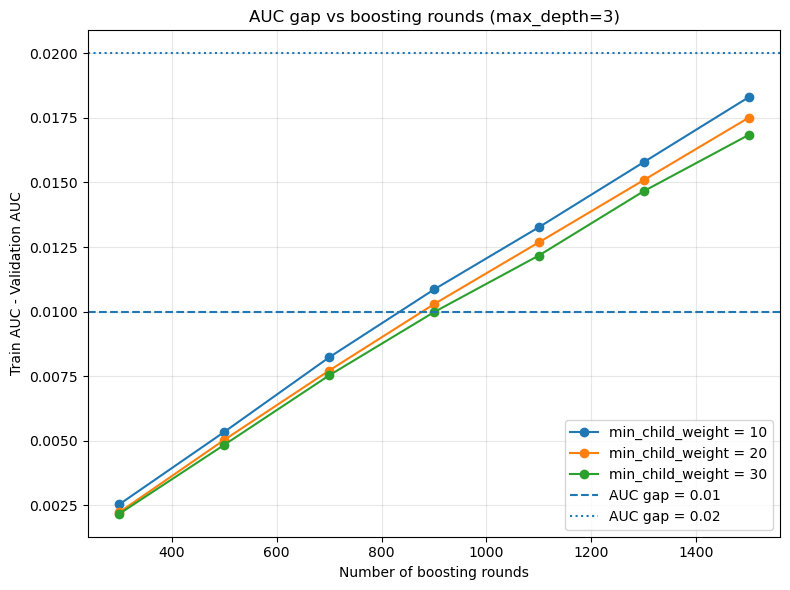

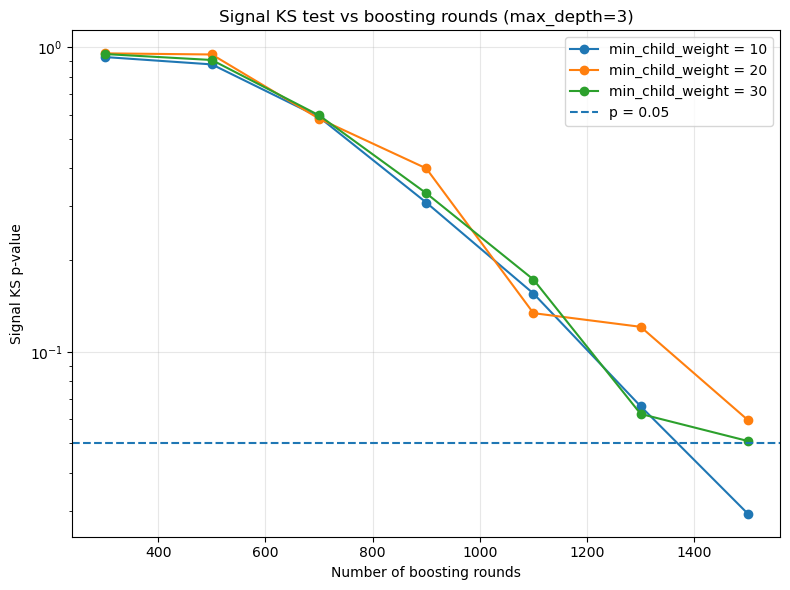

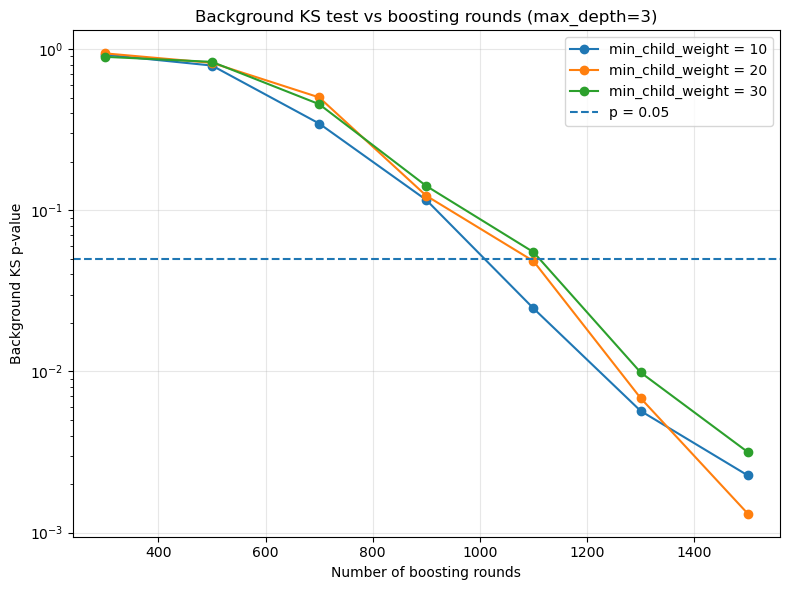


TOP 10 BY VALIDATION AUC


,max_depth,min_child_weight,num_boost_round,train_auc,val_auc,auc_gap,ks_sig_D,ks_sig_p,ks_bkg_D,ks_bkg_p
13,3,20,1500,0.820343,0.802839,0.017504,0.009743,0.059678,0.015125,0.001310
20,3,30,1500,0.819637,0.802800,0.016837,0.009961,0.050915,0.014188,0.003159
6,3,10,1500,0.820917,0.802619,0.018298,0.010682,0.029389,0.014550,0.002263
12,3,20,1300,0.817485,0.802393,0.015091,0.008710,0.120695,0.013313,0.006826
5,3,10,1300,0.818000,0.802214,0.015786,0.009598,0.066200,0.013525,0.005687
19,3,30,1300,0.816844,0.802181,0.014663,0.009679,0.062482,0.012875,0.009852
11,3,20,1100,0.814348,0.801666,0.012683,0.008548,0.133853,0.010775,0.048349
4,3,10,1100,0.814827,0.801560,0.013267,0.008310,0.155259,0.011713,0.024611
18,3,30,1100,0.813723,0.801550,0.012173,0.008136,0.172558,0.010587,0.054967
10,3,20,900,0.810870,0.800581,0.010289,0.006577,0.399850,0.009325,0.122960



CONSERVATIVE CANDIDATES
Conditions: AUC gap < 0.02, signal KS p > 0.05, background KS p > 0.05


,max_depth,min_child_weight,num_boost_round,train_auc,val_auc,auc_gap,ks_sig_D,ks_sig_p,ks_bkg_D,ks_bkg_p
0,3,30,1100,0.813723,0.801550,0.012173,0.008136,0.172558,0.010587,0.054967
1,3,20,900,0.810870,0.800581,0.010289,0.006577,0.399850,0.009325,0.122960
2,3,10,900,0.811248,0.800390,0.010858,0.007096,0.308861,0.009425,0.115796
3,3,30,900,0.810356,0.800376,0.009980,0.006959,0.331368,0.009087,0.141434
4,3,20,700,0.806787,0.799068,0.007719,0.005708,0.582197,0.006525,0.501424
5,3,10,700,0.807106,0.798876,0.008230,0.005678,0.589159,0.007387,0.345274
6,3,30,700,0.806371,0.798841,0.007531,0.005642,0.597133,0.006763,0.455182
7,3,30,500,0.801353,0.796510,0.004843,0.004148,0.907149,0.004912,0.832877
8,3,20,500,0.801516,0.796481,0.005035,0.003854,0.945751,0.004975,0.821357
9,3,10,500,0.801722,0.796379,0.005343,0.004332,0.877458,0.005138,0.790215



HIGHEST VALIDATION AUC AMONG CONSERVATIVE CANDIDATES
max_depth       = 3
min_child_weight = 30
num_boost_round  = 1100
Train AUC        = 0.813723
Validation AUC   = 0.801550
AUC gap          = 0.012173
Signal KS p      = 0.172558
Background KS p  = 0.0549673


In [40]:
# ============================================================
# Boost-round scan with overtraining diagnostics
#
# Scan:
#   - max_depth = 3 fixed
#   - min_child_weight = 10, 20, 30
#   - num_boost_round = 300 ~ 1500
#
# Evaluate:
#   - Train AUC
#   - Validation AUC
#   - AUC gap
#   - KS p-value (signal/background)
#
# IMPORTANT:
#   num_boost_round is fixed for each scan point.
#   No early stopping is used here because the purpose is to
#   explicitly study performance vs boosting round.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp


# ------------------------------------------------------------
# 1. Scan configuration
# ------------------------------------------------------------

MAX_DEPTH_SCAN = 3

MIN_CHILD_WEIGHT_SCAN = [
    10,
    20,
    30,
]

NUM_BOOST_SCAN = [
    300,
    500,
    700,
    900,
    1100,
    1300,
    1500,
]


# ------------------------------------------------------------
# 2. Helper: get XGBoost predictions
# ------------------------------------------------------------

def predict_xgb(model, dmatrix):
    return model.predict(dmatrix)


# ------------------------------------------------------------
# 3. Scan
# ------------------------------------------------------------

boost_scan_results = []

for min_child_weight in MIN_CHILD_WEIGHT_SCAN:

    print()
    print("=" * 80)
    print(
        f"Scanning max_depth={MAX_DEPTH_SCAN}, "
        f"min_child_weight={min_child_weight}"
    )
    print("=" * 80)

    for n_round in NUM_BOOST_SCAN:

        scan_params = params.copy()

        scan_params["max_depth"] = MAX_DEPTH_SCAN
        scan_params["min_child_weight"] = min_child_weight

        # ----------------------------------------------------
        # Train exactly n_round trees
        #
        # No early stopping here:
        # we want to explicitly see what happens as the number
        # of boosting rounds increases.
        # ----------------------------------------------------

        model_scan = xgb.train(
            scan_params,
            dtrain,
            num_boost_round=n_round,
            evals=[
                (dtrain, "train"),
                (dval, "val"),
            ],
            verbose_eval=False,
        )

        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        pred_train = predict_xgb(
            model_scan,
            dtrain,
        )

        pred_val = predict_xgb(
            model_scan,
            dval,
        )

        # ----------------------------------------------------
        # Weighted AUC
        # ----------------------------------------------------

        train_auc = roc_auc_score(
            ytr,
            pred_train,
            sample_weight=wtr,
        )

        val_auc = roc_auc_score(
            yva,
            pred_val,
            sample_weight=wva,
        )

        auc_gap = train_auc - val_auc

        # ----------------------------------------------------
        # KS overtraining test
        #
        # Same convention as your current notebook:
        # scipy KS is UNWEIGHTED.
        # ----------------------------------------------------

        ytr_np = np.asarray(ytr)
        yva_np = np.asarray(yva)

        train_sig_score = pred_train[ytr_np == 1]
        val_sig_score   = pred_val[yva_np == 1]

        train_bkg_score = pred_train[ytr_np == 0]
        val_bkg_score   = pred_val[yva_np == 0]

        ks_sig = ks_2samp(
            train_sig_score,
            val_sig_score,
        )

        ks_bkg = ks_2samp(
            train_bkg_score,
            val_bkg_score,
        )

        boost_scan_results.append({

            "max_depth":
                MAX_DEPTH_SCAN,

            "min_child_weight":
                min_child_weight,

            "num_boost_round":
                n_round,

            "train_auc":
                train_auc,

            "val_auc":
                val_auc,

            "auc_gap":
                auc_gap,

            "ks_sig_D":
                ks_sig.statistic,

            "ks_sig_p":
                ks_sig.pvalue,

            "ks_bkg_D":
                ks_bkg.statistic,

            "ks_bkg_p":
                ks_bkg.pvalue,
        })

        print(
            f"child={min_child_weight:2d} "
            f"round={n_round:4d} | "
            f"train={train_auc:.6f} "
            f"val={val_auc:.6f} "
            f"gap={auc_gap:.6f} | "
            f"KS(sig)={ks_sig.pvalue:.4g} "
            f"KS(bkg)={ks_bkg.pvalue:.4g}"
        )


# ------------------------------------------------------------
# 4. DataFrame
# ------------------------------------------------------------

boost_scan_df = pd.DataFrame(
    boost_scan_results
)

print()
print("=" * 100)
print("BOOST ROUND SCAN RESULTS")
print("=" * 100)

display(
    boost_scan_df.sort_values(
        "val_auc",
        ascending=False,
    )
)


# ============================================================
# 5. Plot: Validation AUC
# ============================================================

plt.figure(figsize=(8, 6))

for child in MIN_CHILD_WEIGHT_SCAN:

    temp = boost_scan_df[
        boost_scan_df["min_child_weight"] == child
    ].sort_values("num_boost_round")

    plt.plot(
        temp["num_boost_round"],
        temp["val_auc"],
        marker="o",
        label=f"min_child_weight = {child}",
    )

plt.xlabel("Number of boosting rounds")
plt.ylabel("Validation ROC AUC")
plt.title(
    f"Validation AUC vs boosting rounds "
    f"(max_depth={MAX_DEPTH_SCAN})"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 6. Plot: Train-validation AUC gap
# ============================================================

plt.figure(figsize=(8, 6))

for child in MIN_CHILD_WEIGHT_SCAN:

    temp = boost_scan_df[
        boost_scan_df["min_child_weight"] == child
    ].sort_values("num_boost_round")

    plt.plot(
        temp["num_boost_round"],
        temp["auc_gap"],
        marker="o",
        label=f"min_child_weight = {child}",
    )

plt.axhline(
    0.01,
    linestyle="--",
    label="AUC gap = 0.01",
)

plt.axhline(
    0.02,
    linestyle=":",
    label="AUC gap = 0.02",
)

plt.xlabel("Number of boosting rounds")
plt.ylabel("Train AUC - Validation AUC")
plt.title(
    f"AUC gap vs boosting rounds "
    f"(max_depth={MAX_DEPTH_SCAN})"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 7. Plot: Signal KS p-value
# ============================================================

plt.figure(figsize=(8, 6))

for child in MIN_CHILD_WEIGHT_SCAN:

    temp = boost_scan_df[
        boost_scan_df["min_child_weight"] == child
    ].sort_values("num_boost_round")

    plt.plot(
        temp["num_boost_round"],
        temp["ks_sig_p"],
        marker="o",
        label=f"min_child_weight = {child}",
    )

plt.axhline(
    0.05,
    linestyle="--",
    label="p = 0.05",
)

plt.yscale("log")

plt.xlabel("Number of boosting rounds")
plt.ylabel("Signal KS p-value")
plt.title(
    f"Signal KS test vs boosting rounds "
    f"(max_depth={MAX_DEPTH_SCAN})"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 8. Plot: Background KS p-value
# ============================================================

plt.figure(figsize=(8, 6))

for child in MIN_CHILD_WEIGHT_SCAN:

    temp = boost_scan_df[
        boost_scan_df["min_child_weight"] == child
    ].sort_values("num_boost_round")

    plt.plot(
        temp["num_boost_round"],
        temp["ks_bkg_p"],
        marker="o",
        label=f"min_child_weight = {child}",
    )

plt.axhline(
    0.05,
    linestyle="--",
    label="p = 0.05",
)

plt.yscale("log")

plt.xlabel("Number of boosting rounds")
plt.ylabel("Background KS p-value")
plt.title(
    f"Background KS test vs boosting rounds "
    f"(max_depth={MAX_DEPTH_SCAN})"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 9. Useful candidate tables
# ============================================================

print()
print("=" * 100)
print("TOP 10 BY VALIDATION AUC")
print("=" * 100)

display(
    boost_scan_df
    .sort_values(
        "val_auc",
        ascending=False,
    )
    .head(10)
)


# ------------------------------------------------------------
# Relatively conservative candidates
#
# NOTE:
# These are diagnostic cuts, NOT universal statistical criteria.
# ------------------------------------------------------------

conservative_candidates = boost_scan_df[
    (boost_scan_df["auc_gap"] < 0.02)
    &
    (boost_scan_df["ks_sig_p"] > 0.05)
    &
    (boost_scan_df["ks_bkg_p"] > 0.05)
].copy()


print()
print("=" * 100)
print("CONSERVATIVE CANDIDATES")
print(
    "Conditions: "
    "AUC gap < 0.02, "
    "signal KS p > 0.05, "
    "background KS p > 0.05"
)
print("=" * 100)

if len(conservative_candidates) > 0:

    conservative_candidates = (
        conservative_candidates
        .sort_values(
            "val_auc",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    display(
        conservative_candidates
    )

    best_conservative = (
        conservative_candidates.iloc[0]
    )

    print()
    print("=" * 100)
    print("HIGHEST VALIDATION AUC AMONG CONSERVATIVE CANDIDATES")
    print("=" * 100)

    print(
        f"max_depth       = "
        f"{int(best_conservative['max_depth'])}"
    )

    print(
        f"min_child_weight = "
        f"{int(best_conservative['min_child_weight'])}"
    )

    print(
        f"num_boost_round  = "
        f"{int(best_conservative['num_boost_round'])}"
    )

    print(
        f"Train AUC        = "
        f"{best_conservative['train_auc']:.6f}"
    )

    print(
        f"Validation AUC   = "
        f"{best_conservative['val_auc']:.6f}"
    )

    print(
        f"AUC gap          = "
        f"{best_conservative['auc_gap']:.6f}"
    )

    print(
        f"Signal KS p      = "
        f"{best_conservative['ks_sig_p']:.6g}"
    )

    print(
        f"Background KS p  = "
        f"{best_conservative['ks_bkg_p']:.6g}"
    )

else:

    print(
        "No scan point satisfies all conservative conditions."
    )

SCAN_TAG = MHc130_depth2-4_child5-30_round500_20260824_155023
Saved: hyperparameter_scan/scan_results_MHc130_depth2-4_child5-30_round500_20260824_155023.csv
Saved: hyperparameter_scan/scan_summary_MHc130_depth2-4_child5-30_round500_20260824_155023.txt


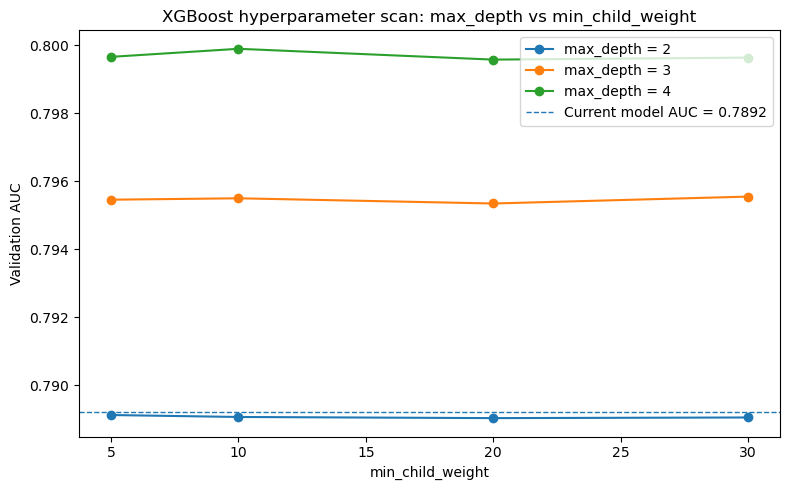

Saved: hyperparameter_scan/scan_val_auc_MHc130_depth2-4_child5-30_round500_20260824_155023.png
Saved: hyperparameter_scan/pdf/scan_val_auc_MHc130_depth2-4_child5-30_round500_20260824_155023.pdf


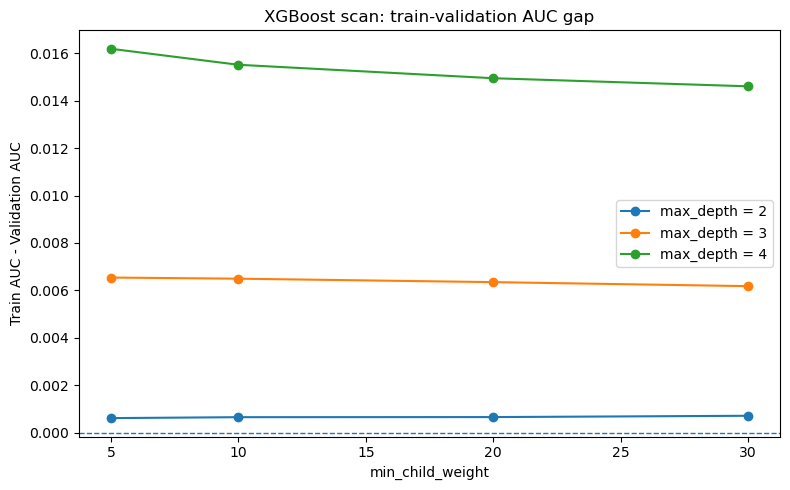

Saved: hyperparameter_scan/scan_auc_gap_MHc130_depth2-4_child5-30_round500_20260824_155023.png
Saved: hyperparameter_scan/pdf/scan_auc_gap_MHc130_depth2-4_child5-30_round500_20260824_155023.pdf

SCAN SAVED
Best: max_depth=4, min_child_weight=10
Validation AUC = 0.799891
Train AUC      = 0.815400
AUC gap        = 0.015509
Signal KS p    = 0.3290
Background KS p= 0.0265

CSV : hyperparameter_scan/scan_results_MHc130_depth2-4_child5-30_round500_20260824_155023.csv
TXT : hyperparameter_scan/scan_summary_MHc130_depth2-4_child5-30_round500_20260824_155023.txt
PNG : hyperparameter_scan/scan_val_auc_MHc130_depth2-4_child5-30_round500_20260824_155023.png
PDF : hyperparameter_scan/pdf/scan_val_auc_MHc130_depth2-4_child5-30_round500_20260824_155023.pdf
PNG : hyperparameter_scan/scan_auc_gap_MHc130_depth2-4_child5-30_round500_20260824_155023.png
PDF : hyperparameter_scan/pdf/scan_auc_gap_MHc130_depth2-4_child5-30_round500_20260824_155023.pdf


In [35]:
# ============================================================
# Save hyperparameter scan results
#
# Saves:
#   1. Full scan table                 -> CSV
#   2. Human-readable summary          -> TXT
#   3. Validation AUC scan plot        -> PNG / PDF
#   4. AUC-gap scan plot               -> PNG / PDF
#
# This does NOT save/overwrite the XGBoost model or ONNX.
# ============================================================

from pathlib import Path
from datetime import datetime

# ============================================================
# 1. Output directories
# ============================================================

SCAN_DIR = Path("./hyperparameter_scan")
SCAN_PDF_DIR = SCAN_DIR / "pdf"

SCAN_DIR.mkdir(parents=True, exist_ok=True)
SCAN_PDF_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

SCAN_TAG = (
    f"MHc130_"
    f"depth{min(SCAN_MAX_DEPTH)}-{max(SCAN_MAX_DEPTH)}_"
    f"child{min(SCAN_MIN_CHILD_WEIGHT)}-{max(SCAN_MIN_CHILD_WEIGHT)}_"
    f"round{SCAN_NUM_BOOST_ROUND}_"
    f"{timestamp}"
)

print("SCAN_TAG =", SCAN_TAG)


# ============================================================
# 2. Save full numerical results
# ============================================================

csv_path = SCAN_DIR / f"scan_results_{SCAN_TAG}.csv"

scan_df.to_csv(
    csv_path,
    index=False,
)

print("Saved:", csv_path)


# ============================================================
# 3. Best point
# ============================================================

best = scan_df.iloc[0]

best_depth = int(best["max_depth"])
best_child = int(best["min_child_weight"])
best_iteration = int(best["best_iteration"])

best_train_auc = float(best["train_auc"])
best_val_auc = float(best["val_auc"])
best_auc_gap = float(best["auc_gap"])

best_train_logloss = float(best["train_logloss"])
best_val_logloss = float(best["val_logloss"])

best_ks_sig_p = float(best["ks_sig_p"])
best_ks_bkg_p = float(best["ks_bkg_p"])


# ============================================================
# 4. Save readable TXT summary
# ============================================================

txt_path = SCAN_DIR / f"scan_summary_{SCAN_TAG}.txt"

with open(txt_path, "w") as f:

    f.write(
        "========== XGBoost Hyperparameter Scan ==========\n"
    )

    f.write(
        f"Saved at              : "
        f"{datetime.now().isoformat()}\n"
    )

    f.write(
        f"Scan tag              : {SCAN_TAG}\n"
    )

    f.write("\n")

    f.write(
        "========== Scan Configuration ==========\n"
    )

    f.write(
        f"max_depth values      : "
        f"{SCAN_MAX_DEPTH}\n"
    )

    f.write(
        f"min_child_weight      : "
        f"{SCAN_MIN_CHILD_WEIGHT}\n"
    )

    f.write(
        f"num_boost_round       : "
        f"{SCAN_NUM_BOOST_ROUND}\n"
    )

    f.write(
        f"early stopping rounds : "
        f"{SCAN_EARLY_STOPPING_ROUNDS}\n"
    )

    f.write(
        f"random seed           : "
        f"{SCAN_RANDOM_SEED}\n"
    )

    f.write("\n")

    f.write(
        "========== Dataset ==========\n"
    )

    f.write(
        f"Train entries         : "
        f"{len(scan_train)}\n"
    )

    f.write(
        f"Validation entries    : "
        f"{len(scan_val)}\n"
    )

    f.write(
        f"Train signal          : "
        f"{(y_train_scan == 1).sum()}\n"
    )

    f.write(
        f"Train background      : "
        f"{(y_train_scan == 0).sum()}\n"
    )

    f.write(
        f"Validation signal     : "
        f"{(y_val_scan == 1).sum()}\n"
    )

    f.write(
        f"Validation background : "
        f"{(y_val_scan == 0).sum()}\n"
    )

    f.write("\n")

    f.write(
        "========== Best Validation AUC ==========\n"
    )

    f.write(
        f"max_depth             : "
        f"{best_depth}\n"
    )

    f.write(
        f"min_child_weight      : "
        f"{best_child}\n"
    )

    f.write(
        f"best_iteration        : "
        f"{best_iteration}\n"
    )

    f.write(
        f"Train AUC             : "
        f"{best_train_auc:.10f}\n"
    )

    f.write(
        f"Validation AUC        : "
        f"{best_val_auc:.10f}\n"
    )

    f.write(
        f"AUC gap               : "
        f"{best_auc_gap:.10f}\n"
    )

    f.write(
        f"Train logloss         : "
        f"{best_train_logloss:.10f}\n"
    )

    f.write(
        f"Validation logloss    : "
        f"{best_val_logloss:.10f}\n"
    )

    f.write(
        f"Signal KS p-value     : "
        f"{best_ks_sig_p:.10f}\n"
    )

    f.write(
        f"Background KS p-value : "
        f"{best_ks_bkg_p:.10f}\n"
    )

    f.write("\n")

    f.write(
        "========== Full Scan Results ==========\n"
    )

    f.write(
        scan_df.to_string(index=False)
    )

    f.write("\n")

print("Saved:", txt_path)


# ============================================================
# 5. Save Validation AUC plot
# ============================================================

plt.figure(figsize=(8, 5))

for depth in SCAN_MAX_DEPTH:

    temp = (
        scan_df[
            scan_df["max_depth"] == depth
        ]
        .sort_values("min_child_weight")
    )

    plt.plot(
        temp["min_child_weight"],
        temp["val_auc"],
        marker="o",
        label=f"max_depth = {depth}",
    )

# Current baseline model
plt.axhline(
    0.7892074689,
    linestyle="--",
    linewidth=1,
    label="Current model AUC = 0.7892",
)

plt.xlabel("min_child_weight")
plt.ylabel("Validation AUC")

plt.title(
    "XGBoost hyperparameter scan: "
    "max_depth vs min_child_weight"
)

plt.legend()
plt.tight_layout()

auc_png = (
    SCAN_DIR
    / f"scan_val_auc_{SCAN_TAG}.png"
)

auc_pdf = (
    SCAN_PDF_DIR
    / f"scan_val_auc_{SCAN_TAG}.pdf"
)

plt.savefig(
    auc_png,
    dpi=180,
    bbox_inches="tight",
)

plt.savefig(
    auc_pdf,
    bbox_inches="tight",
)

plt.show()

print("Saved:", auc_png)
print("Saved:", auc_pdf)


# ============================================================
# 6. Save AUC-gap plot
# ============================================================

plt.figure(figsize=(8, 5))

for depth in SCAN_MAX_DEPTH:

    temp = (
        scan_df[
            scan_df["max_depth"] == depth
        ]
        .sort_values("min_child_weight")
    )

    plt.plot(
        temp["min_child_weight"],
        temp["auc_gap"],
        marker="o",
        label=f"max_depth = {depth}",
    )

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel("min_child_weight")
plt.ylabel("Train AUC - Validation AUC")
plt.title("XGBoost scan: train-validation AUC gap")

plt.legend()
plt.tight_layout()

gap_png = (
    SCAN_DIR
    / f"scan_auc_gap_{SCAN_TAG}.png"
)

gap_pdf = (
    SCAN_PDF_DIR
    / f"scan_auc_gap_{SCAN_TAG}.pdf"
)

plt.savefig(
    gap_png,
    dpi=180,
    bbox_inches="tight",
)

plt.savefig(
    gap_pdf,
    bbox_inches="tight",
)

plt.show()

print("Saved:", gap_png)
print("Saved:", gap_pdf)


# ============================================================
# 7. Final summary
# ============================================================

print()
print("============================================================")
print("SCAN SAVED")
print("============================================================")

print(
    f"Best: max_depth={best_depth}, "
    f"min_child_weight={best_child}"
)

print(
    f"Validation AUC = {best_val_auc:.6f}"
)

print(
    f"Train AUC      = {best_train_auc:.6f}"
)

print(
    f"AUC gap        = {best_auc_gap:.6f}"
)

print(
    f"Signal KS p    = {best_ks_sig_p:.4f}"
)

print(
    f"Background KS p= {best_ks_bkg_p:.4f}"
)

print()
print("CSV :", csv_path)
print("TXT :", txt_path)
print("PNG :", auc_png)
print("PDF :", auc_pdf)
print("PNG :", gap_png)
print("PDF :", gap_pdf)

In [20]:
# ============================================================
# Boost-round scan
#
# IMPORTANT:
# - Use exactly the SAME signal/background sample as main training
# - Use exactly the SAME train/validation split for every round
# - Keep ml_weight unchanged
# - Change ONLY num_boost_round
# ============================================================
from sklearn.metrics import roc_curve, roc_auc_score
RUN_SCAN = False

if RUN_SCAN:
    SCAN_N_BKG = N_BKG
    scan_rounds = [400, 450, 500, 550, 600]
    scan_results = []

    # ========================================================
    # 1. Reproduce the SAME dataset definition as main training
    # ========================================================

    scan_sig = df_sig_clean.copy()

    scan_bkg = df_bkg_clean.copy()

    if SCAN_N_BKG is not None and len(scan_bkg) > SCAN_N_BKG:
        scan_bkg = (
            scan_bkg
            .sample(
                n=SCAN_N_BKG,
                random_state=RANDOM_SEED,
            )
            .reset_index(drop=True)
        )

    scan_all = pd.concat(
        [scan_sig, scan_bkg],
        ignore_index=True,
    )

    print("Scan dataset:")
    print("  signal     =", len(scan_sig))
    print("  background =", len(scan_bkg))
    print("  total      =", len(scan_all))

    print()
    print("Class weight sums before split:")
    print(
        scan_all.groupby(LABEL_COL)["ml_weight"].sum()
    )


    # ========================================================
    # 2. ONE fixed train/validation split
    #
    # Every boost-round point uses exactly these same events.
    # ========================================================

    scan_train, scan_val = train_test_split(
        scan_all,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=scan_all[LABEL_COL],
    )

    print()
    print("Fixed split:")
    print("  train =", len(scan_train))
    print("  val   =", len(scan_val))

    print()
    print("Train labels:")
    print(scan_train[LABEL_COL].value_counts().sort_index())

    print()
    print("Validation labels:")
    print(scan_val[LABEL_COL].value_counts().sort_index())


    # ========================================================
    # 3. Inputs
    # ========================================================

    Xtr_raw = scan_train[FEATURES].astype(float)
    Xva_raw = scan_val[FEATURES].astype(float)

    ytr = scan_train[LABEL_COL].astype(int)
    yva = scan_val[LABEL_COL].astype(int)

    wtr = scan_train["ml_weight"].astype(float)
    wva = scan_val["ml_weight"].astype(float)


    # ========================================================
    # 4. SAME preprocessing as main training
    # ========================================================

    if SCALER_TYPE is None:
        Xtr = Xtr_raw.copy()
        Xva = Xva_raw.copy()

    elif SCALER_TYPE == "standard":
        scan_scaler = StandardScaler()

        Xtr = pd.DataFrame(
            scan_scaler.fit_transform(Xtr_raw),
            columns=FEATURES,
            index=Xtr_raw.index,
        )

        Xva = pd.DataFrame(
            scan_scaler.transform(Xva_raw),
            columns=FEATURES,
            index=Xva_raw.index,
        )

    elif SCALER_TYPE == "minmax":
        scan_scaler = MinMaxScaler()

        Xtr = pd.DataFrame(
            scan_scaler.fit_transform(Xtr_raw),
            columns=FEATURES,
            index=Xtr_raw.index,
        )

        Xva = pd.DataFrame(
            scan_scaler.transform(Xva_raw),
            columns=FEATURES,
            index=Xva_raw.index,
        )

    else:
        raise ValueError(
            f"Unknown SCALER_TYPE: {SCALER_TYPE}"
        )


    # ========================================================
    # 5. DMatrix
    # ========================================================

    dtr_scan = xgb.DMatrix(
        Xtr,
        label=ytr,
        weight=wtr,
        feature_names=FEATURES,
    )

    dva_scan = xgb.DMatrix(
        Xva,
        label=yva,
        weight=wva,
        feature_names=FEATURES,
    )


    # ========================================================
    # 6. Round scan
    #
    # NO early stopping here:
    # we want the actual performance at each fixed round.
    # ========================================================

    for n_round in scan_rounds:

        m = xgb.train(
            params,
            dtr_scan,
            num_boost_round=n_round,
            evals=[
                (dtr_scan, "train"),
                (dva_scan, "validation"),
            ],
            verbose_eval=False,
        )

        pred_tr = m.predict(dtr_scan)
        pred_va = m.predict(dva_scan)


        # ----------------------------------------------------
        # Weighted AUC
        # ----------------------------------------------------

        auc_tr = roc_auc_score(
            ytr,
            pred_tr,
            sample_weight=wtr,
        )

        auc_va = roc_auc_score(
            yva,
            pred_va,
            sample_weight=wva,
        )


        # ----------------------------------------------------
        # Unweighted KS
        #
        # Same definition as main notebook.
        # ----------------------------------------------------

        ytr_np = ytr.to_numpy()
        yva_np = yva.to_numpy()

        ks_sig = ks_2samp(
            pred_tr[ytr_np == 1],
            pred_va[yva_np == 1],
        )

        ks_bkg = ks_2samp(
            pred_tr[ytr_np == 0],
            pred_va[yva_np == 0],
        )


        # ----------------------------------------------------
        # Store result
        # ----------------------------------------------------

        scan_results.append({
            "num_boost_round": n_round,
            "train_auc": auc_tr,
            "val_auc": auc_va,
            "auc_gap": auc_tr - auc_va,
            "ks_sig_D": ks_sig.statistic,
            "ks_sig_p": ks_sig.pvalue,
            "ks_bkg_D": ks_bkg.statistic,
            "ks_bkg_p": ks_bkg.pvalue,
        })


    # ========================================================
    # 7. Result table
    # ========================================================

    scan_df = pd.DataFrame(scan_results)

    display(
        scan_df.style.format({
            "train_auc": "{:.6f}",
            "val_auc": "{:.6f}",
            "auc_gap": "{:.6f}",
            "ks_sig_D": "{:.4f}",
            "ks_sig_p": "{:.4f}",
            "ks_bkg_D": "{:.4f}",
            "ks_bkg_p": "{:.4f}",
        })
    )


    # ========================================================
    # 8. Best validation AUC
    # ========================================================

    best_row = scan_df.loc[
        scan_df["val_auc"].idxmax()
    ]

    print()
    print("Best validation AUC point:")
    print(best_row)

## 10. Evaluation: ROC and score distributions


Train AUC      = 0.789682
Validation AUC = 0.789207
AUC gap        = 0.000474


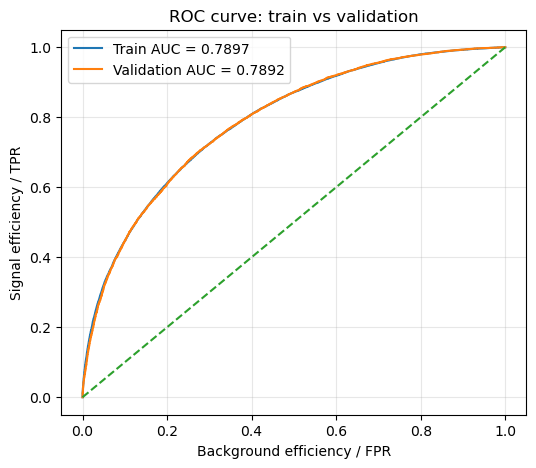

In [21]:
from sklearn.metrics import roc_curve, auc as sklearn_auc


# ============================================================
# Predictions
# ============================================================

pred_train = model.predict(dtrain)
pred_val = model.predict(dval)


# ============================================================
# Train ROC / AUC
# ============================================================

fpr_train, tpr_train, _ = roc_curve(
    y_train,
    pred_train,
    sample_weight=w_train,
)

auc_train = sklearn_auc(
    fpr_train,
    tpr_train,
)


# ============================================================
# Validation ROC / AUC
# ============================================================

fpr_val, tpr_val, _ = roc_curve(
    y_val,
    pred_val,
    sample_weight=w_val,
)

auc_val = sklearn_auc(
    fpr_val,
    tpr_val,
)


# ============================================================
# Print AUC comparison
# ============================================================

print(f"Train AUC      = {auc_train:.6f}")
print(f"Validation AUC = {auc_val:.6f}")
print(f"AUC gap        = {auc_train - auc_val:.6f}")


# ============================================================
# ROC curve: train vs validation
# ============================================================

plt.figure(figsize=(6, 5))

plt.plot(
    fpr_train,
    tpr_train,
    label=f"Train AUC = {auc_train:.4f}",
)

plt.plot(
    fpr_val,
    tpr_val,
    label=f"Validation AUC = {auc_val:.4f}",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.xlabel("Background efficiency / FPR")
plt.ylabel("Signal efficiency / TPR")
plt.title("ROC curve: train vs validation")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

AUC = 0.7892074688614289


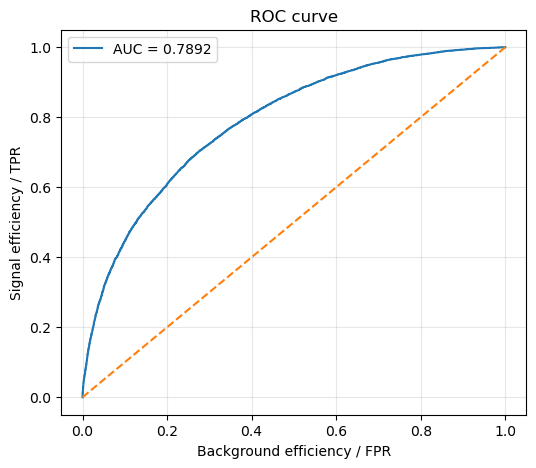

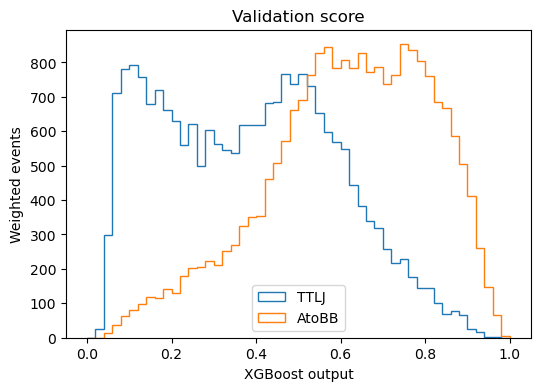

In [22]:
from sklearn.metrics import roc_curve, auc as sklearn_auc

y_pred = model.predict(dval)

fpr, tpr, thresholds = roc_curve(y_val, y_pred, sample_weight=w_val)
auc_val = sklearn_auc(fpr, tpr)
print("AUC =", auc_val)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_val:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Background efficiency / FPR")
plt.ylabel("Signal efficiency / TPR")
plt.title("ROC curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0,1), histtype="step", weights=w_val[y_val == 0], label="TTLJ")
plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0,1), histtype="step", weights=w_val[y_val == 1], label="AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Weighted events")
plt.legend()
plt.title("Validation score")
plt.show()


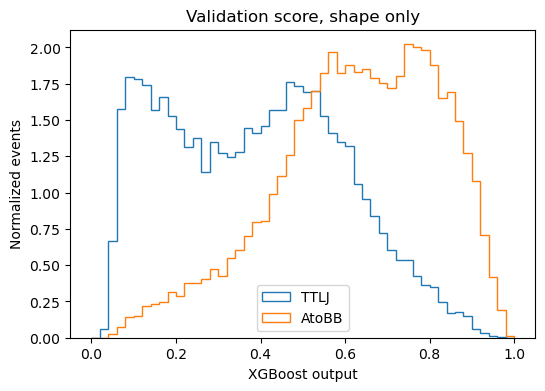

In [23]:
plt.figure(figsize=(6,4))
plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0,1),
         histtype="step", density=True, label="TTLJ")
plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0,1),
         histtype="step", density=True, label="AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Normalized events")
plt.legend()
plt.title("Validation score, shape only")
plt.show()

## 11. Overtraining check

Compare train vs validation score shapes.


[KS overtraining check]
Signal:     D = 0.0047, p = 0.808
Background: D = 0.0053, p = 0.7653


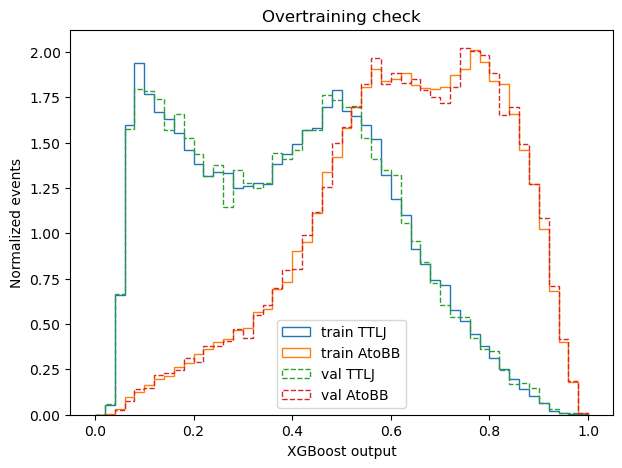

In [24]:
pred_train = model.predict(dtrain)
pred_val = model.predict(dval)

y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
w_train_np = w_train.to_numpy()
w_val_np = w_val.to_numpy()

# ============================================================
# [ADDED] Kolmogorov-Smirnov overtraining test
#
# Compare:
#   signal train vs signal validation
#   bkg    train vs bkg    validation
#
# Do NOT compare signal vs background here.
# That would measure discrimination, not overtraining.
#
# scipy.stats.ks_2samp is UNWEIGHTED.
# ============================================================

ks_sig = ks_2samp(
    pred_train[y_train_np == 1],
    pred_val[y_val_np == 1],
)

ks_bkg = ks_2samp(
    pred_train[y_train_np == 0],
    pred_val[y_val_np == 0],
)


print("[KS overtraining check]")

print(
    f"Signal:     "
    f"D = {ks_sig.statistic:.4f}, "
    f"p = {ks_sig.pvalue:.4g}"
)

print(
    f"Background: "
    f"D = {ks_bkg.statistic:.4f}, "
    f"p = {ks_bkg.pvalue:.4g}"
)

plt.figure(figsize=(7, 5))
plt.hist(pred_train[y_train_np == 0], bins=50, range=(0, 1), histtype="step", density=True, label="train TTLJ")
plt.hist(pred_train[y_train_np == 1], bins=50, range=(0, 1), histtype="step", density=True, label="train AtoBB")
plt.hist(pred_val[y_val_np == 0], bins=50, range=(0, 1), histtype="step", density=True, linestyle="--", label="val TTLJ")
plt.hist(pred_val[y_val_np == 1], bins=50, range=(0, 1), histtype="step", density=True, linestyle="--", label="val AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Normalized events")
plt.title("Overtraining check")
plt.legend()
plt.show()


## 12. Feature importance


              feature         gain
0     bb_mass_min_all  2877.945312
1       bb_dr_min_all   769.264587
2              nBJets   515.534180
3   bb_mass_at_min_dr   495.953674
4       bbbW_mass_012   486.414093
5                  ST   230.443741
6       bblnu_mass_12   211.321732
7               nJets   173.209061
8     bb_mass_max_all   167.264038
9            bb_dr_12   160.142868
10                 HT   120.399773
11           bb_dr_01   119.229485
12          best_chi2   108.306892
13       had_top_mass   106.879295
14      bblnu_mass_02   101.596184
15      bblnu_mass_01    98.237411
16           bb_dr_02    97.701355
17       lep_top_mass    81.462891
18         bb_mass_12    75.235321
19         bb_mass_02    72.905716
20         lep_W_mass    69.414444
21         bb_mass_01    60.958443
22       bbjj_mass_12    58.606976
23         had_W_mass    54.967319
24            jj_mass    44.224567
25           lnu_mass    41.251007
26         Lepton0_Pt    41.139160
27             MET_P

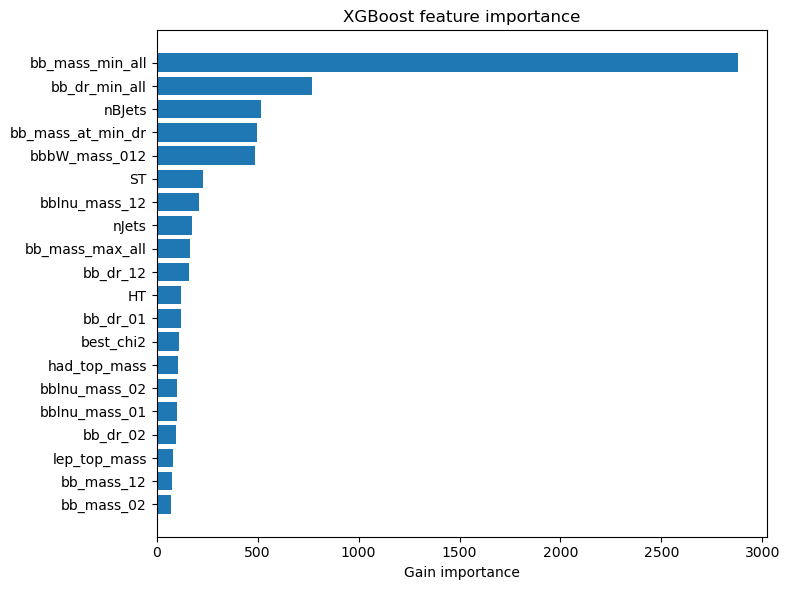

In [25]:
importance = model.get_score(importance_type="gain")
importance_named = []
for key, val in importance.items():
    # key is like f0, f1, ...
    idx = int(key[1:]) if key.startswith("f") else int(key)
    importance_named.append((used_columns[idx], val))
importance_named = sorted(importance_named, key=lambda x: x[1], reverse=True)

imp_df = pd.DataFrame(importance_named, columns=["feature", "gain"])
print(imp_df.head(30))

plt.figure(figsize=(8,6))
plot_df = imp_df.head(20).iloc[::-1]
plt.barh(plot_df["feature"], plot_df["gain"])
plt.xlabel("Gain importance")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()


In [27]:
# ============================================================
# Save ALL training information + validation/overtraining plots
# ============================================================
import os, sys, platform
from datetime import datetime
import sklearn, scipy
from sklearn.metrics import roc_curve, auc as sklearn_auc
from scipy.stats import ks_2samp

# ---------- output directory / tag ----------
PLOT_DIR = f"{MODEL_DIR}/scan_plots_0824_bb3massxx_bblnu3massxx_Amassxx_MHc130"
PDF_DIR = f"{PLOT_DIR}/pdf"
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(PDF_DIR, exist_ok=True)

scaler_tag = "none" if SCALER_TYPE is None else str(SCALER_TYPE)
nbkg_tag = "all" if N_BKG is None else str(N_BKG)
# tag = f"MHc{int(TARGET_MHc)}_MA{int(TARGET_MA)}_nbkg{nbkg_tag}_boost{NUM_BOOST_ROUND}_{scaler_tag}"
tag = f"MHc{int(TARGET_MHc)}_nbkg{nbkg_tag}_boost{NUM_BOOST_ROUND}_{scaler_tag}"

def save_current_results(tag):
    # ---------- predictions / arrays ----------
    pred_train = model.predict(dtrain)
    pred_val = model.predict(dval)
    y_train_np, y_val_np = y_train.to_numpy(), y_val.to_numpy()
    w_train_np, w_val_np = w_train.to_numpy(), w_val.to_numpy()

    # ---------- AUC ----------
    fpr_train, tpr_train, _ = roc_curve(y_train_np, pred_train, sample_weight=w_train_np)
    fpr_val, tpr_val, _ = roc_curve(y_val_np, pred_val, sample_weight=w_val_np)
    auc_train = sklearn_auc(fpr_train, tpr_train)
    auc_val = sklearn_auc(fpr_val, tpr_val)
    auc_gap = auc_train - auc_val

    # ---------- KS: train vs validation, separately for S/B ----------
    # NOTE: scipy ks_2samp is unweighted.
    ks_sig = ks_2samp(pred_train[y_train_np == 1], pred_val[y_val_np == 1])
    ks_bkg = ks_2samp(pred_train[y_train_np == 0], pred_val[y_val_np == 0])

    # ---------- feature importance ----------
    importance = model.get_score(importance_type="gain")
    importance_named = []
    for key, val in importance.items():
        if key in used_columns:
            name = key
        elif key.startswith("f") and key[1:].isdigit():
            idx = int(key[1:])
            name = used_columns[idx] if idx < len(used_columns) else key
        else:
            name = key
        importance_named.append((name, val))
    importance_named = sorted(importance_named, key=lambda x: x[1], reverse=True)
    imp_df = pd.DataFrame(importance_named, columns=["feature", "gain"])
    imp_df.to_csv(f"{PLOT_DIR}/feature_importance_{tag}.csv", index=False)

    # ========================================================
    # 1. Validation-only ROC
    # ========================================================
    plt.figure(figsize=(6,5))
    plt.plot(fpr_val, tpr_val, label=f"Validation AUC = {auc_val:.4f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("Background efficiency / FPR"); plt.ylabel("Signal efficiency / TPR")
    plt.title(f"Validation ROC: {tag}"); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/roc_validation_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/roc_validation_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 2. Train vs validation ROC
    # ========================================================
    plt.figure(figsize=(6,5))
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.4f}")
    plt.plot(fpr_val, tpr_val, label=f"Validation AUC = {auc_val:.4f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("Background efficiency / FPR"); plt.ylabel("Signal efficiency / TPR")
    plt.title(f"ROC: train vs validation\nAUC gap = {auc_gap:.4f}")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/roc_train_vs_val_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/roc_train_vs_val_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 3. Validation score, weighted
    # ========================================================
    plt.figure(figsize=(6,4))
    plt.hist(pred_val[y_val_np == 0], bins=50, range=(0,1), histtype="step", density=True,
             weights=w_val_np[y_val_np == 0], label="TTLJ")
    plt.hist(pred_val[y_val_np == 1], bins=50, range=(0,1), histtype="step", density=True,
             weights=w_val_np[y_val_np == 1], label="AtoBB")
    plt.xlabel("XGBoost output"); plt.ylabel("Normalized weighted events")
    plt.title(f"Validation score: {tag}"); plt.legend(); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/score_validation_weighted_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/score_validation_weighted_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 4. Validation score, shape only
    # ========================================================
    plt.figure(figsize=(6,4))
    plt.hist(pred_val[y_val_np == 0], bins=50, range=(0,1), histtype="step", density=True, label="TTLJ")
    plt.hist(pred_val[y_val_np == 1], bins=50, range=(0,1), histtype="step", density=True, label="AtoBB")
    plt.xlabel("XGBoost output"); plt.ylabel("Normalized events")
    plt.title(f"Validation score, shape only: {tag}"); plt.legend(); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/score_validation_shape_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/score_validation_shape_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 5. Overtraining check: weighted train vs validation
    # ========================================================
    plt.figure(figsize=(7,5))
    plt.hist(pred_train[y_train_np == 0], bins=50, range=(0,1), histtype="step", density=True,
             weights=w_train_np[y_train_np == 0], label="Train TTLJ")
    plt.hist(pred_train[y_train_np == 1], bins=50, range=(0,1), histtype="step", density=True,
             weights=w_train_np[y_train_np == 1], label="Train AtoBB")
    plt.hist(pred_val[y_val_np == 0], bins=50, range=(0,1), histtype="step", density=True, linestyle="--",
             weights=w_val_np[y_val_np == 0], label="Val TTLJ")
    plt.hist(pred_val[y_val_np == 1], bins=50, range=(0,1), histtype="step", density=True, linestyle="--",
             weights=w_val_np[y_val_np == 1], label="Val AtoBB")
    plt.xlabel("XGBoost output"); plt.ylabel("Normalized weighted events")
    plt.title(f"Overtraining check: {tag}"); plt.legend(); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/overtraining_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/overtraining_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 6. Learning curve: train / validation logloss
    # ========================================================
    train_loss = evals_result["train"]["logloss"]
    val_loss = evals_result["validation"]["logloss"]
    try: best_iteration = int(model.best_iteration)
    except: best_iteration = None
    try: best_score = float(model.best_score)
    except: best_score = None

    plt.figure(figsize=(7,4))
    plt.plot(train_loss, label="Train logloss")
    plt.plot(val_loss, label="Validation logloss")
    if best_iteration is not None:
        plt.axvline(best_iteration, linestyle="--", label=f"Best iteration = {best_iteration}")
    plt.xlabel("Boosting round"); plt.ylabel("Logloss")
    plt.title(f"Learning curve: {tag}"); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/learning_curve_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/learning_curve_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 7. KS CDF visualization
    # ========================================================
    def ecdf(x):
        x = np.sort(np.asarray(x))
        return x, np.arange(1, len(x)+1) / len(x)

    plt.figure(figsize=(7,5))
    for arr, label, ls in [
        (pred_train[y_train_np == 1], "Train AtoBB", "-"), (pred_val[y_val_np == 1], "Val AtoBB", "--"),
        (pred_train[y_train_np == 0], "Train TTLJ", "-"), (pred_val[y_val_np == 0], "Val TTLJ", "--")
    ]:
        x, y = ecdf(arr); plt.plot(x, y, linestyle=ls, label=label)
    plt.xlabel("XGBoost output"); plt.ylabel("Empirical CDF")
    plt.title(f"KS check: Signal p={ks_sig.pvalue:.3g}, Bkg p={ks_bkg.pvalue:.3g}")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/ks_cdf_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/ks_cdf_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 8. Feature importance
    # ========================================================
    # XGBoost internal feature name -> real feature name
    feature_map = {f"f{i}": feat for i, feat in enumerate(FEATURES)}
    feature_map.update({str(i): feat for i, feat in enumerate(FEATURES)})

    imp_plot_df = imp_df.copy()
    imp_plot_df["feature_name"] = imp_plot_df["feature"].astype(str).map(feature_map)

    # 혹시 이미 실제 이름으로 들어있는 경우도 처리
    imp_plot_df["feature_name"] = imp_plot_df["feature_name"].fillna(
        imp_plot_df["feature"].astype(str)
    )

    # gain 큰 순서 top 20
    plot_df = imp_plot_df.sort_values("gain", ascending=False).head(20).iloc[::-1]

    plt.figure(figsize=(10, 7))
    plt.barh(plot_df["feature_name"], plot_df["gain"])
    plt.xlabel("Gain importance")
    plt.title(f"XGBoost feature importance: {tag}")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/importance_{tag}.png", dpi=150, bbox_inches="tight")
    plt.close()
    # ========================================================
    # 9. Save ALL training configuration/results to TXT
    # ========================================================
    info_path = f"{PLOT_DIR}/training_info_{tag}.txt"
    early_stopping_rounds = globals().get("EARLY_STOPPING_ROUNDS", 50)
    actual_rounds = len(train_loss)

    # ROOT entry counts from input files (before N_BKG sampling)
    def root_entries(paths):
        result = []
        for path in paths:
            f = ROOT.TFile.Open(path, "READ")
            tree = f.Get(TREE_NAME) if f and not f.IsZombie() else None
            result.append((path, int(tree.GetEntries()) if tree else -1))
            if f: f.Close()
        return result

    sig_root_entries = root_entries(SIG_FILES)
    bkg_root_entries = root_entries(BKG_FILES)

    with open(info_path, "w") as f:
        f.write("========== XGBoost AtoBB Training Record ==========\n")
        f.write(f"Saved at              : {datetime.now().isoformat()}\n")
        f.write(f"Tag                   : {tag}\n")
        f.write(f"Model name            : {globals().get('MODEL_NAME', 'N/A')}\n")
        f.write(f"Tree name             : {TREE_NAME}\n")
        f.write(f"TARGET_MHc            : {TARGET_MHc}\n")
        # f.write(f"TARGET_MA             : {TARGET_MA}\n\n")
        f.write(f"Signal MA points      : {MASS_POINTS}\n")
        f.write("Mass-independent      : True\n\n")

        f.write("========== Input Samples ==========\n")
        f.write("Signal files:\n")
        for path, n in sig_root_entries: f.write(f"  {path}\n    ROOT entries = {n}\n")
        f.write("Background files:\n")
        for path, n in bkg_root_entries: f.write(f"  {path}\n    ROOT entries = {n}\n")
        f.write(f"N_BKG requested       : {N_BKG}\n")
        f.write(f"Signal after loading  : {len(df_sig)}\n")
        f.write(f"Bkg after limit       : {len(df_bkg)}\n")
        f.write(f"Signal after cleaning : {len(df_sig_clean)}\n")
        f.write(f"Bkg after cleaning    : {len(df_bkg_clean)}\n\n")

        f.write("========== Train / Validation ==========\n")
        f.write(f"Random seed           : {globals().get('RANDOM_SEED', 42)}\n")
        f.write(f"Train entries         : {len(train_df)}\n")
        f.write(f"Validation entries    : {len(val_df)}\n")
        f.write(f"Train signal          : {int((y_train_np == 1).sum())}\n")
        f.write(f"Train background      : {int((y_train_np == 0).sum())}\n")
        f.write(f"Validation signal     : {int((y_val_np == 1).sum())}\n")
        f.write(f"Validation background : {int((y_val_np == 0).sum())}\n")
        f.write(f"Training weight       : {globals().get('WEIGHT_COL', 'weight_train')} -> ml_weight\n")
        f.write(f"Sum train weights     : {w_train_np.sum():.10g}\n")
        f.write(f"Sum validation weights: {w_val_np.sum():.10g}\n\n")

        f.write("========== Preprocessing ==========\n")
        f.write(f"SCALER_TYPE           : {SCALER_TYPE}\n")
        f.write(f"Number of features    : {len(used_columns)}\n")
        f.write("Feature order:\n")
        for i, feat in enumerate(used_columns): f.write(f"  {i:02d}: {feat}\n")

        f.write("\n========== XGBoost Configuration ==========\n")
        f.write(f"NUM_BOOST_ROUND requested : {NUM_BOOST_ROUND}\n")
        f.write(f"Actual rounds run         : {actual_rounds}\n")
        f.write(f"Early stopping rounds     : {early_stopping_rounds}\n")
        f.write(f"Best iteration            : {best_iteration}\n")
        f.write(f"Best score                : {best_score}\n")
        f.write("Parameters:\n")
        for key, value in params.items(): f.write(f"  {key}: {value}\n")

        f.write("\n========== Performance ==========\n")
        f.write(f"Train AUC             : {auc_train:.10f}\n")
        f.write(f"Validation AUC        : {auc_val:.10f}\n")
        f.write(f"AUC gap               : {auc_gap:.10f}\n")
        f.write(f"Final train logloss   : {train_loss[-1]:.10f}\n")
        f.write(f"Final val logloss     : {val_loss[-1]:.10f}\n")
        if best_iteration is not None and best_iteration < len(val_loss):
            f.write(f"Train logloss @ best  : {train_loss[best_iteration]:.10f}\n")
            f.write(f"Val logloss @ best    : {val_loss[best_iteration]:.10f}\n")

        f.write("\n========== KS Overtraining Test ==========\n")
        f.write("NOTE: scipy.stats.ks_2samp is an UNWEIGHTED KS test.\n")
        f.write(f"Signal KS D           : {ks_sig.statistic:.10f}\n")
        f.write(f"Signal KS p-value     : {ks_sig.pvalue:.10g}\n")
        f.write(f"Background KS D       : {ks_bkg.statistic:.10f}\n")
        f.write(f"Background KS p-value : {ks_bkg.pvalue:.10g}\n")

        f.write("\n========== Feature Importance (gain) ==========\n")
        for i, row in imp_df.iterrows(): f.write(f"{i+1:02d}. {row['feature']:<35s} {row['gain']:.10g}\n")

        f.write("\n========== Software ==========\n")
        f.write(f"Python                : {sys.version.replace(chr(10),' ')}\n")
        f.write(f"Platform              : {platform.platform()}\n")
        f.write(f"NumPy                 : {np.__version__}\n")
        f.write(f"Pandas                : {pd.__version__}\n")
        f.write(f"XGBoost               : {xgb.__version__}\n")
        f.write(f"scikit-learn          : {sklearn.__version__}\n")
        f.write(f"SciPy                 : {scipy.__version__}\n")
        f.write(f"ROOT                   : {ROOT.gROOT.GetVersion()}\n")

        f.write("\n========== Saved Files ==========\n")
        for name in [
            f"roc_validation_{tag}.png", f"roc_train_vs_val_{tag}.png",
            f"score_validation_weighted_{tag}.png", f"score_validation_shape_{tag}.png",
            f"overtraining_{tag}.png", f"learning_curve_{tag}.png",
            f"ks_cdf_{tag}.png", f"importance_{tag}.png",
            f"feature_importance_{tag}.csv"
        ]: f.write(f"  {name}\n")

    print("\n========== SAVED ==========")
    print("Directory      :", PLOT_DIR)
    print("Training info  :", info_path)
    print("Feature CSV    :", f"{PLOT_DIR}/feature_importance_{tag}.csv")
    print(f"Train AUC      : {auc_train:.6f}")
    print(f"Validation AUC : {auc_val:.6f}")
    print(f"AUC gap        : {auc_gap:.6f}")
    print(f"Signal KS      : D={ks_sig.statistic:.4f}, p={ks_sig.pvalue:.4g}")
    print(f"Background KS  : D={ks_bkg.statistic:.4f}, p={ks_bkg.pvalue:.4g}")
    print("Best iteration :", best_iteration)
    print("Scaler         :", SCALER_TYPE)
    return auc_val

auc_val = save_current_results(tag)


========== SAVED ==========
Directory      : /data9/Users/eunsu/MachineLearning/models/scan_plots_0824_bb3massxx_bblnu3massxx_Amassxx_MHc130
Training info  : /data9/Users/eunsu/MachineLearning/models/scan_plots_0824_bb3massxx_bblnu3massxx_Amassxx_MHc130/training_info_MHc130_nbkg100000_boost500_none.txt
Feature CSV    : /data9/Users/eunsu/MachineLearning/models/scan_plots_0824_bb3massxx_bblnu3massxx_Amassxx_MHc130/feature_importance_MHc130_nbkg100000_boost500_none.csv
Train AUC      : 0.789682
Validation AUC : 0.789207
AUC gap        : 0.000474
Signal KS      : D=0.0047, p=0.808
Background KS  : D=0.0053, p=0.7653
Best iteration : 499
Scaler         : None


In [28]:
print("===== BEFORE TRAIN/VAL SPLIT =====")
print("Signal total:", len(df_sig_clean))
print("Background total:", len(df_bkg_clean))

print("\nSignal by MA:")
print(df_sig_clean.groupby("mass_point").size())

print("\n===== TRAIN =====")
print("Total:", len(train_df))
print("Signal:", (train_df[LABEL_COL] == 1).sum())
print("Background:", (train_df[LABEL_COL] == 0).sum())

print("\nSignal train by MA:")
print(
    train_df[train_df[LABEL_COL] == 1]
    .groupby("mass_point")
    .size()
)

print("\n===== VALIDATION =====")
print("Total:", len(val_df))
print("Signal:", (val_df[LABEL_COL] == 1).sum())
print("Background:", (val_df[LABEL_COL] == 0).sum())

print("\nSignal validation by MA:")
print(
    val_df[val_df[LABEL_COL] == 1]
    .groupby("mass_point")
    .size()
)

===== BEFORE TRAIN/VAL SPLIT =====
Signal total: 115391
Background total: 100000

Signal by MA:
mass_point
18     13011
25     14319
36     14207
50     17756
70     17393
90     15765
110    12045
125    10895
dtype: int64

===== TRAIN =====
Total: 172312
Signal: 92312
Background: 80000

Signal train by MA:
mass_point
18     10409
25     11455
36     11365
50     14205
70     13914
90     12612
110     9636
125     8716
dtype: int64

===== VALIDATION =====
Total: 43079
Signal: 23079
Background: 20000

Signal validation by MA:
mass_point
18     2602
25     2864
36     2842
50     3551
70     3479
90     3153
110    2409
125    2179
dtype: int64


In [29]:
print(df_sig_clean.groupby("mass_point")["ml_weight"].sum())

mass_point
18     13461.9375
25     13461.9375
36     13461.9375
50     13461.9375
70     13461.9375
90     13461.9375
110    13461.9375
125    13461.9375
Name: ml_weight, dtype: float64


## 13. Export to ONNX

This creates `xgboost_atobb_ttlJ.onnx` and a JSON file containing the exact feature order.

The C++ inference input vector **must use this exact order**.


In [30]:
from onnxmltools.convert.common.data_types import FloatTensorType

initial_type = [("input", FloatTensorType([None, len(used_columns)]))]
onnx_model = convert_xgboost_booster(model, initial_types=initial_type, target_opset=12)
onnx.save_model(onnx_model, ONNX_PATH)

metadata = {
    "features": used_columns,
    "feature_indices": {name: i for i, name in enumerate(used_columns)},
    # ========================================================
    # [ADDED]
    # This classifier is explicitly conditioned on this
    # reconstructed MA hypothesis.
    # ========================================================
    # "target_ma": TARGET_MA,
    "target_mhc": TARGET_MHc,
    "mass_independent": True,
    "signal_ma_points": MASS_POINTS,
    
    "scaler_type": SCALER_TYPE,
    "n_bkg": N_BKG,
    "num_boost_round": NUM_BOOST_ROUND,
    "params": params,
    "auc": float(auc_val),
}

with open(FEATURE_JSON_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

if scaler is not None:
    with open(SCALER_PICKLE_PATH, "wb") as f:
        pickle.dump(scaler, f)

    scaler_json = {
        "scaler_type": SCALER_TYPE,
        "features": used_columns,
    }
    if SCALER_TYPE == "standard":
        scaler_json["mean"] = scaler.mean_.tolist()
        scaler_json["scale"] = scaler.scale_.tolist()
    elif SCALER_TYPE == "minmax":
        scaler_json["min"] = scaler.min_.tolist()
        scaler_json["scale"] = scaler.scale_.tolist()
        scaler_json["data_min"] = scaler.data_min_.tolist()
        scaler_json["data_max"] = scaler.data_max_.tolist()

    with open(SCALER_JSON_PATH, "w") as f:
        json.dump(scaler_json, f, indent=4)

print("Saved ONNX:", ONNX_PATH)
print("Saved feature metadata:", FEATURE_JSON_PATH)
print("Saved scaler json:", SCALER_JSON_PATH)
print("Saved scaler pickle:", SCALER_PICKLE_PATH)

Saved ONNX: /data9/Users/eunsu/MachineLearning/models/xgboost_atobb_MHc130_MAcombined_ttlj.onnx
Saved feature metadata: /data9/Users/eunsu/MachineLearning/models/xgboost_atobb_MHc130_MAcombined_ttlj_features.json
Saved scaler json: /data9/Users/eunsu/MachineLearning/models/xgboost_atobb_MHc130_MAcombined_ttlj_scaler.json
Saved scaler pickle: /data9/Users/eunsu/MachineLearning/models/xgboost_atobb_MHc130_MAcombined_ttlj_scaler.pkl


## 14. Validate ONNX output against XGBoost output

This checks that the exported ONNX model gives the same score as the original XGBoost model.


ONNX inputs: [<onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f3ccd4f8730>]
ONNX outputs: [<onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f3ccd4f8030>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f3ccd4f93b0>]
0 <class 'numpy.ndarray'> (43079,)
1 <class 'numpy.ndarray'> (43079, 2)
ONNX pred ready: (43079,)
max |xgb - onnx| = 3.5762787e-07


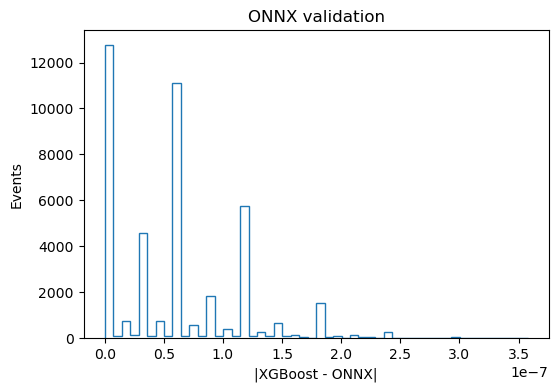

In [31]:
import onnxruntime as ort

sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
print("ONNX inputs:", sess.get_inputs())
print("ONNX outputs:", sess.get_outputs())

X_val_np = X_val.to_numpy(dtype=np.float32)
onnx_outputs = sess.run(None, {"input": X_val_np})

# For binary:logistic conversion, output name/shape can differ by package version.
# Print shapes first.
for i, out in enumerate(onnx_outputs):
    print(i, type(out), getattr(out, "shape", None))

# Try common cases.
y_pred_onnx = None
if len(onnx_outputs) == 1:
    y_pred_onnx = np.asarray(onnx_outputs[0]).reshape(-1)
else:
    # Often: labels, probabilities. probabilities may be array or list of dicts.
    prob = onnx_outputs[-1]
    if isinstance(prob, list):
        y_pred_onnx = np.array([p[1] if 1 in p else p.get("1") for p in prob], dtype=float)
    else:
        prob = np.asarray(prob)
        if prob.ndim == 2 and prob.shape[1] >= 2:
            y_pred_onnx = prob[:, 1]
        else:
            y_pred_onnx = prob.reshape(-1)

print("ONNX pred ready:", y_pred_onnx.shape)
print("max |xgb - onnx| =", np.max(np.abs(y_pred - y_pred_onnx)))

plt.figure(figsize=(6,4))
plt.hist(np.abs(y_pred - y_pred_onnx), bins=50, histtype="step")
plt.xlabel("|XGBoost - ONNX|")
plt.ylabel("Events")
plt.title("ONNX validation")
plt.show()


## 15. C++ inference note

For SKNano C++ inference, use the exact feature order saved in `xgboost_atobb_ttlJ_features.json`.

The input shape should be:

```cpp
input_shape_xgboost["input"] = {1, N_FEATURES};
```

where `N_FEATURES` is printed above.
